<a href="https://colab.research.google.com/github/shrav-jally/CIFAR-10-Exploration/blob/main/DLLabCIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow keras numpy matplotlib

In [ ]:
#loading, preprocessing and extracting shape
import keras
from keras import layers, datasets
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset (Integrated in Keras)
(X_train_full, y_train_full), (X_test_full, y_test_full) = datasets.cifar10.load_data()

# 2. Extract and print Shapes/Sizes
print(f"Full Training set shape: {X_train_full.shape}") # (50000, 32, 32, 3)
print(f"Full Test set shape: {X_test_full.shape}")     # (10000, 32, 32, 3)
print(f"Image Resolution: {X_train_full.shape[1]}x{X_train_full.shape[2]}")
print(f"Channels: {X_train_full.shape[3]} (RGB)")

# 3. Normalize pixel values to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test_full = X_test_full.astype('float32') / 255.0

# 4. Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = 10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Full Training set shape: (50000, 32, 32, 3)
Full Test set shape: (10000, 32, 32, 3)
Image Resolution: 32x32
Channels: 3 (RGB)


In [ ]:
#inducing overfitting through split
from sklearn.model_selection import train_test_split

# We will only use 5% of the total data for training to force the model to overfit
# 5% of 50,000 = 2,500 images (still more than CMU, but small for CIFAR)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_train_full, y_train_full,
    test_size=0.95,
    stratify=y_train_full,
    random_state=42
)

# Use the rest for a large Validation and Test set to check generalization
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val = keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test = keras.utils.to_categorical(y_test, NUM_CLASSES)

print(f"Intentionally small Train set: {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")

Intentionally small Train set: 2500 images
Validation set: 23750 images


In [ ]:
#baseline cnn
from keras import models, layers

def build_baseline_model():
    model = models.Sequential([
        # Layer 1: Look for simple edges/colors
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Layer 2: Look for more complex patterns
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Layer 3: Final refinement of features
        layers.Conv2D(64, (3, 3), activation='relu'),

        # Head: Flatten the 3D features into 1D for classification
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax') # 10 class output
    ])
    return model

# Create and compile
baseline_model = build_baseline_model()
baseline_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Train for 30 epochs
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 153ms/step - accuracy: 0.1660 - loss: 2.1721 - val_accuracy: 0.2126 - val_loss: 2.0654
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.2864 - loss: 1.9382 - val_accuracy: 0.3067 - val_loss: 1.8442
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3456 - loss: 1.7656 - val_accuracy: 0.2895 - val_loss: 1.8645
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4004 - loss: 1.6366 - val_accuracy: 0.3757 - val_loss: 1.6748
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4352 - loss: 1.5441 - val_accuracy: 0.3776 - val_loss: 1.7013
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4484 - loss: 1.4915 - val_accuracy: 0.4013 - val_loss: 1.6735
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5016 - loss: 1.3890 - val_accuracy: 0.4201 - val_loss: 1.6166
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5260 - loss: 1.3197 - val_accuracy: 0.4247 -

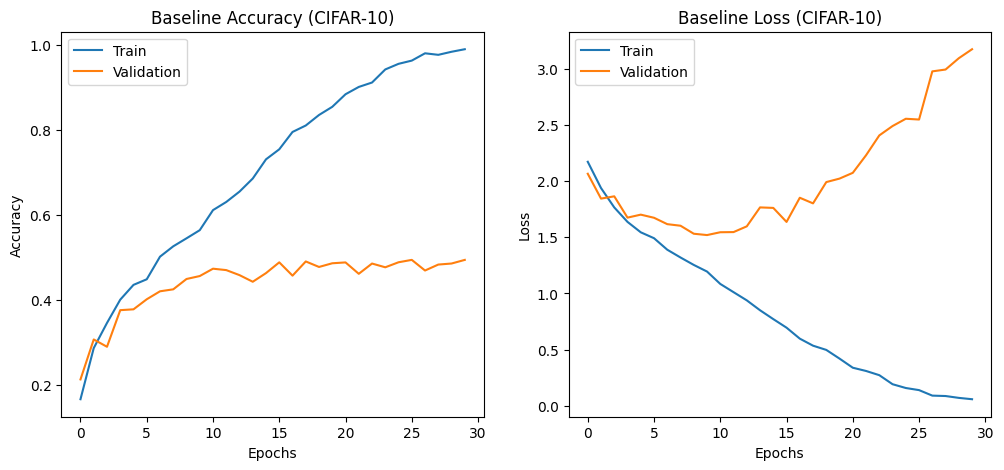

In [ ]:
#plotting learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train')
plt.plot(history_baseline.history['val_accuracy'], label='Validation')
plt.title("Baseline Accuracy (CIFAR-10)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train')
plt.plot(history_baseline.history['val_loss'], label='Validation')
plt.title("Baseline Loss (CIFAR-10)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


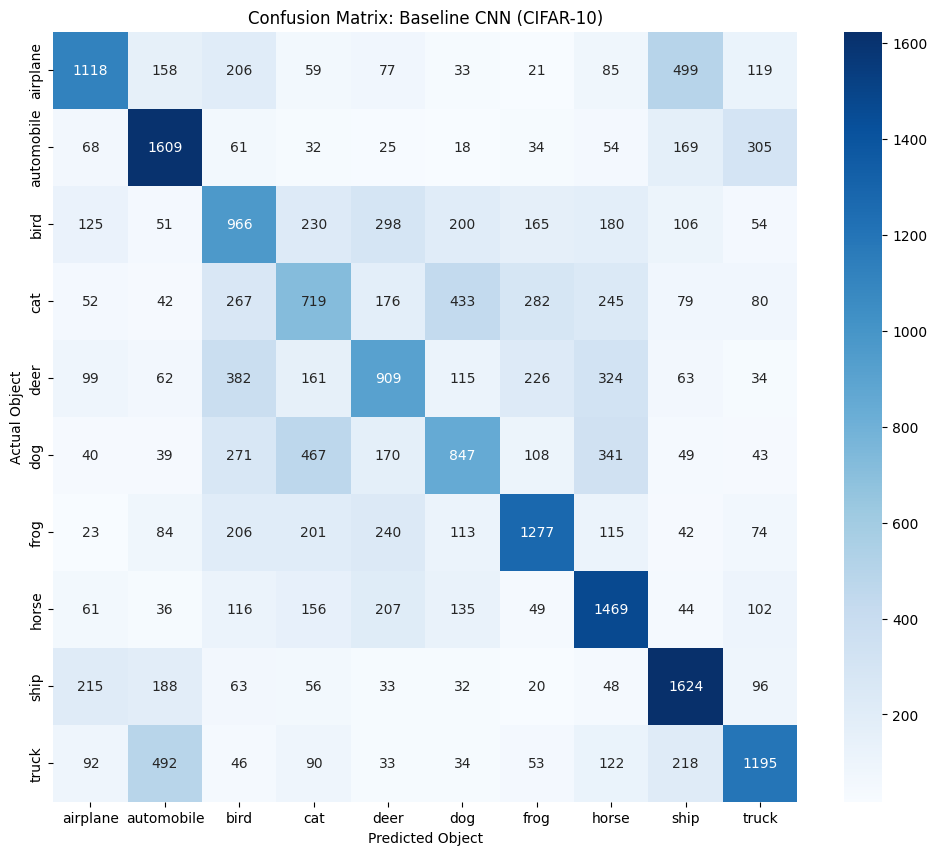

In [ ]:
#plotting confusion matrix
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# 1. Get predictions (probabilities) for the validation set
y_pred_probs = baseline_model.predict(X_val)

# 2. Convert probabilities to class integers
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 3. Convert one-hot encoded validation labels back to integers
y_true_classes = np.argmax(y_val, axis=1)

# 4. Generate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# 5. Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix: Baseline CNN (CIFAR-10)")
plt.xlabel("Predicted Object")
plt.ylabel("Actual Object")
plt.show()


Training with Learning Rate: 0.01

Training with Learning Rate: 0.0001


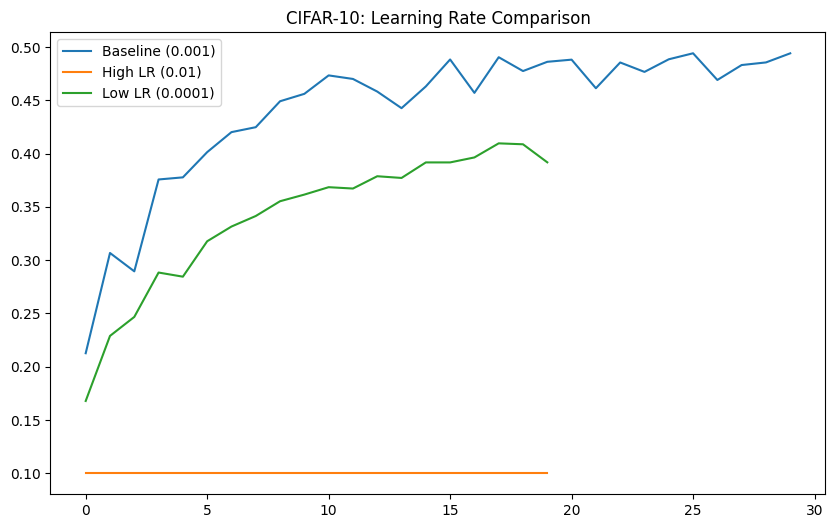

In [ ]:
#experimenting with learning rates
def train_lr_exp(lr_value, name):
    model = build_baseline_model() # Reset architecture
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr_value),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    print(f"\nTraining with Learning Rate: {lr_value}")
    history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                        validation_data=(X_val, y_val), verbose=0)
    return history

# Run experiments
history_high_lr = train_lr_exp(0.01, "High")
history_low_lr = train_lr_exp(0.0001, "Low")

# Plot Comparison
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (0.001)')
plt.plot(history_high_lr.history['val_accuracy'], label='High LR (0.01)')
plt.plot(history_low_lr.history['val_accuracy'], label='Low LR (0.0001)')
plt.title("CIFAR-10: Learning Rate Comparison")
plt.legend()
plt.show()


Training with Batch Size: 8

Training with Batch Size: 256


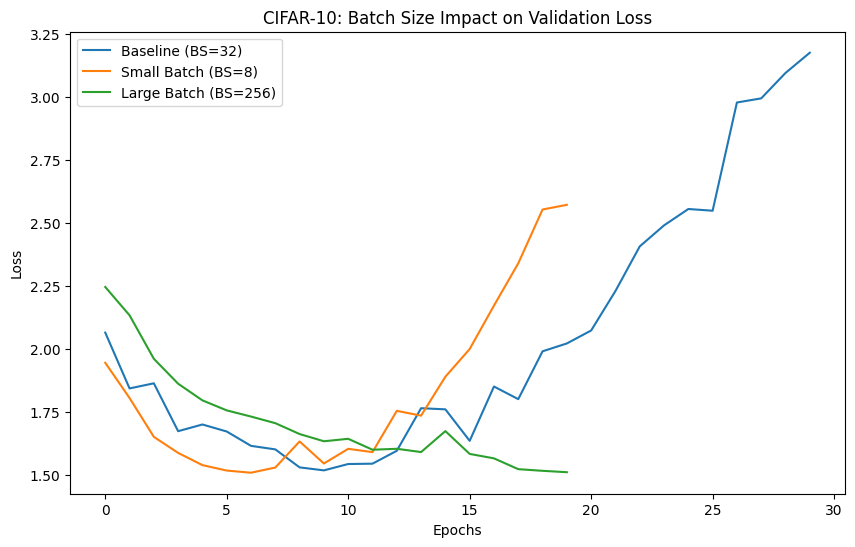

In [ ]:
#experimenting with batch sizes
def train_batch_exp(bs_value, name):
    model = build_baseline_model() # Reset architecture
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print(f"\nTraining with Batch Size: {bs_value}")
    history = model.fit(X_train, y_train, epochs=20, batch_size=bs_value,
                        validation_data=(X_val, y_val), verbose=0)
    return history

# Run batch size experiments
history_small_bs = train_batch_exp(8, "Small")
history_large_bs = train_batch_exp(256, "Large")

# Plot Comparison
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_loss'], label='Baseline (BS=32)')
plt.plot(history_small_bs.history['val_loss'], label='Small Batch (BS=8)')
plt.plot(history_large_bs.history['val_loss'], label='Large Batch (BS=256)')
plt.title("CIFAR-10: Batch Size Impact on Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

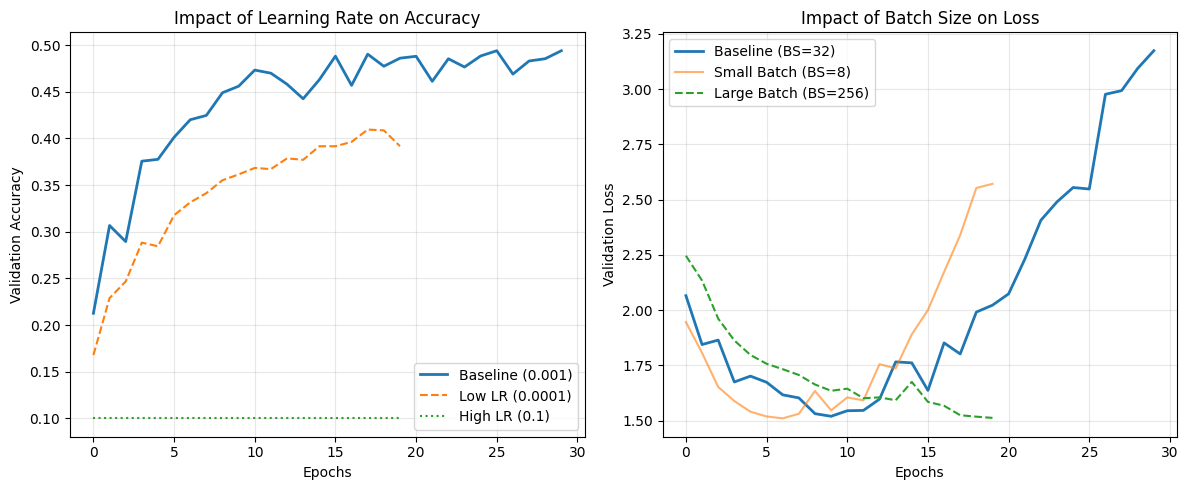

In [ ]:
#plotting learning rate and batch size variations
import matplotlib.pyplot as plt

# Set figure size for better readability
plt.rcParams['figure.figsize'] = [12, 5]

# --- Plot 1: Learning Rate Comparison ---
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (0.001)', linewidth=2)
plt.plot(history_low_lr.history['val_accuracy'], label='Low LR (0.0001)', linestyle='--')
plt.plot(history_high_lr.history['val_accuracy'], label='High LR (0.1)', linestyle=':')
plt.title("Impact of Learning Rate on Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 2: Batch Size Comparison ---
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_loss'], label='Baseline (BS=32)', linewidth=2)
plt.plot(history_small_bs.history['val_loss'], label='Small Batch (BS=8)', alpha=0.6)
plt.plot(history_large_bs.history['val_loss'], label='Large Batch (BS=256)', linestyle='--')
plt.title("Impact of Batch Size on Loss")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lr_bs_variation_comparison.png')

In [ ]:
import matplotlib.pyplot as plt
from keras import models, layers, optimizers

def build_cifar_baseline():
    # Fresh model architecture for each experiment
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Define the 8 configurations
# We use the X_train defined in your earlier 5% split
cifar_experiments = [
    {"name": "1. Batch GD", "opt": optimizers.SGD(0.01), "bs": len(X_train)},
    {"name": "2. Stochastic GD", "opt": optimizers.SGD(0.01), "bs": 1},
    {"name": "3. Mini-batch GD", "opt": optimizers.SGD(0.01), "bs": 32},
    {"name": "4. SGD + Momentum", "opt": optimizers.SGD(0.01, momentum=0.9), "bs": 32},
    {"name": "5. Nesterov", "opt": optimizers.SGD(0.01, momentum=0.9, nesterov=True), "bs": 32},
    {"name": "6. AdaGrad", "opt": optimizers.Adagrad(0.01), "bs": 32},
    {"name": "7. RMSProp", "opt": optimizers.RMSprop(0.001), "bs": 32},
    {"name": "8. Adam", "opt": optimizers.Adam(0.001), "bs": 32},
]

all_histories = {}

# Run the tournament
for exp in cifar_experiments:
    print(f"Testing: {exp['name']}...")
    model = build_cifar_baseline()
    model.compile(optimizer=exp['opt'], loss='categorical_crossentropy', metrics=['accuracy'])

    # We train for 15 epochs to observe convergence speed
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=15,
                        batch_size=exp['bs'],
                        verbose=0)
    all_histories[exp['name']] = history

print("Tournament Complete!")

Testing: 1. Batch GD...
Testing: 2. Stochastic GD...
Testing: 3. Mini-batch GD...
Testing: 4. SGD + Momentum...
Testing: 5. Nesterov...
Testing: 6. AdaGrad...
Testing: 7. RMSProp...
Testing: 8. Adam...
Tournament Complete!


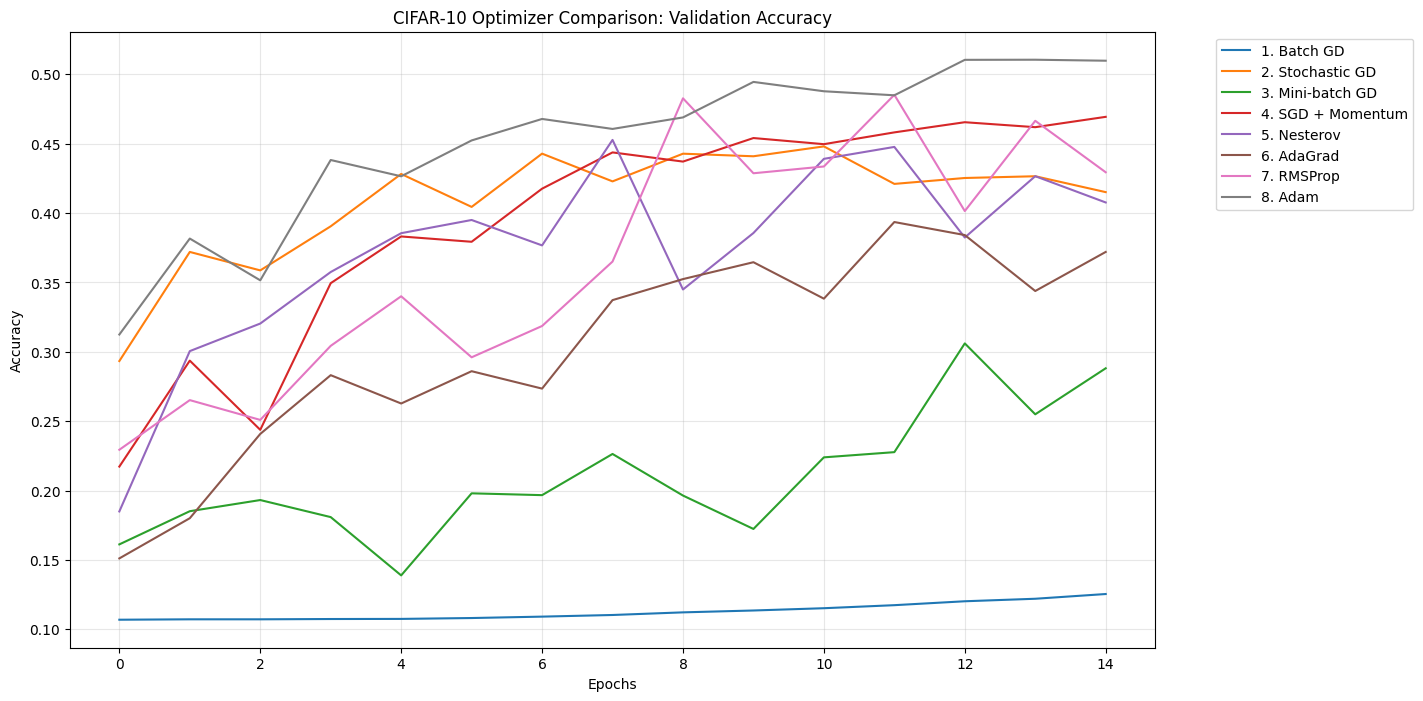

In [ ]:
plt.figure(figsize=(14, 8))

for name, history in all_histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title("CIFAR-10 Optimizer Comparison: Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#implementing optimized model
from keras import regularizers

def build_optimized_cifar_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Conv Layer + L2 Regularization (Keeps weights small)
        layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        # Dropout: Randomly "turns off" 50% of neurons to force better learning
        layers.Dropout(0.5),

        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Final Optimized Run
optimized_model = build_optimized_cifar_model()
optimized_model.compile(
    optimizer=keras.optimizers.Adam(0.001), # Using the 'Adam' logic from your tournament
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_optimized = optimized_model.fit(
    X_train, y_train,
    epochs=50, # More epochs because Dropout makes learning slower but better
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.1584 - loss: 2.2909 - val_accuracy: 0.2018 - val_loss: 2.1855
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.2712 - loss: 2.0375 - val_accuracy: 0.3123 - val_loss: 1.9447
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3436 - loss: 1.8546 - val_accuracy: 0.3436 - val_loss: 1.8166
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3884 - loss: 1.7123 - val_accuracy: 0.3507 - val_loss: 1.8348
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4128 - loss: 1.6495 - val_accuracy: 0.4095 - val_loss: 1.6730
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4668 - loss: 1.5435 - val_accuracy: 0.3784 - val_loss: 1.8403
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4652 - loss: 1.5295 - val_accuracy: 0.4224 - val_loss: 1.6194
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4776 - loss: 1.5151 - val_accuracy: 0.4411 - 

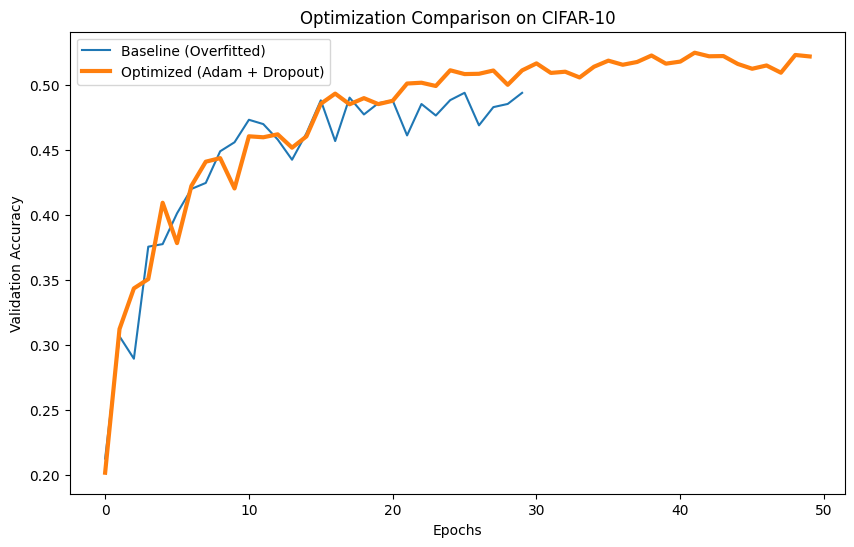

In [ ]:
#visualizing improvement
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (Overfitted)')
plt.plot(history_optimized.history['val_accuracy'], label='Optimized (Adam + Dropout)', linewidth=3)
plt.title("Optimization Comparison on CIFAR-10")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

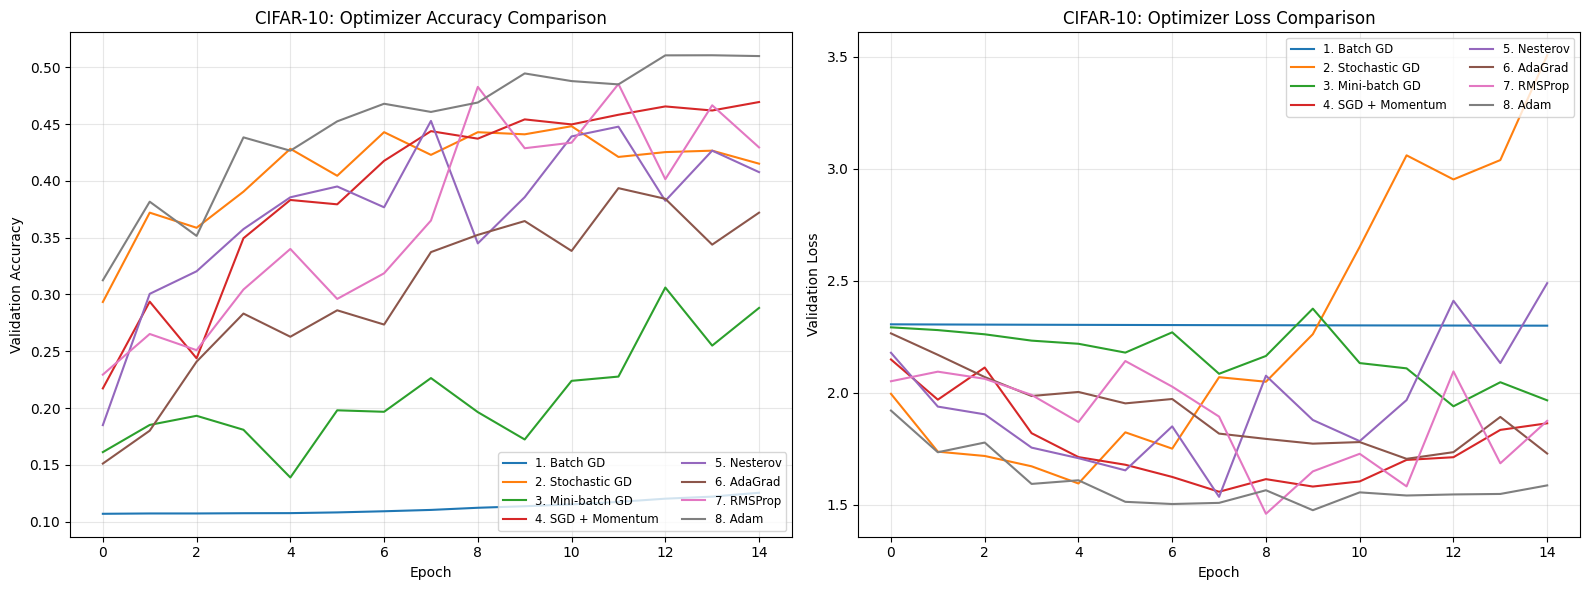

In [ ]:
import matplotlib.pyplot as plt

# Set the figure size to be wide like your professor's example
plt.figure(figsize=(16, 6))

# --- Plot 1: Validation Accuracy Comparison ---
plt.subplot(1, 2, 1)
# Using 'all_histories' which contains your 8 optimizer results
for name, history in all_histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title('CIFAR-10: Optimizer Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right', fontsize='small', ncol=2)
plt.grid(True, alpha=0.3)

# --- Plot 2: Validation Loss Comparison ---
plt.subplot(1, 2, 2)
for name, history in all_histories.items():
    plt.plot(history.history['val_loss'], label=name)

plt.title('CIFAR-10: Optimizer Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


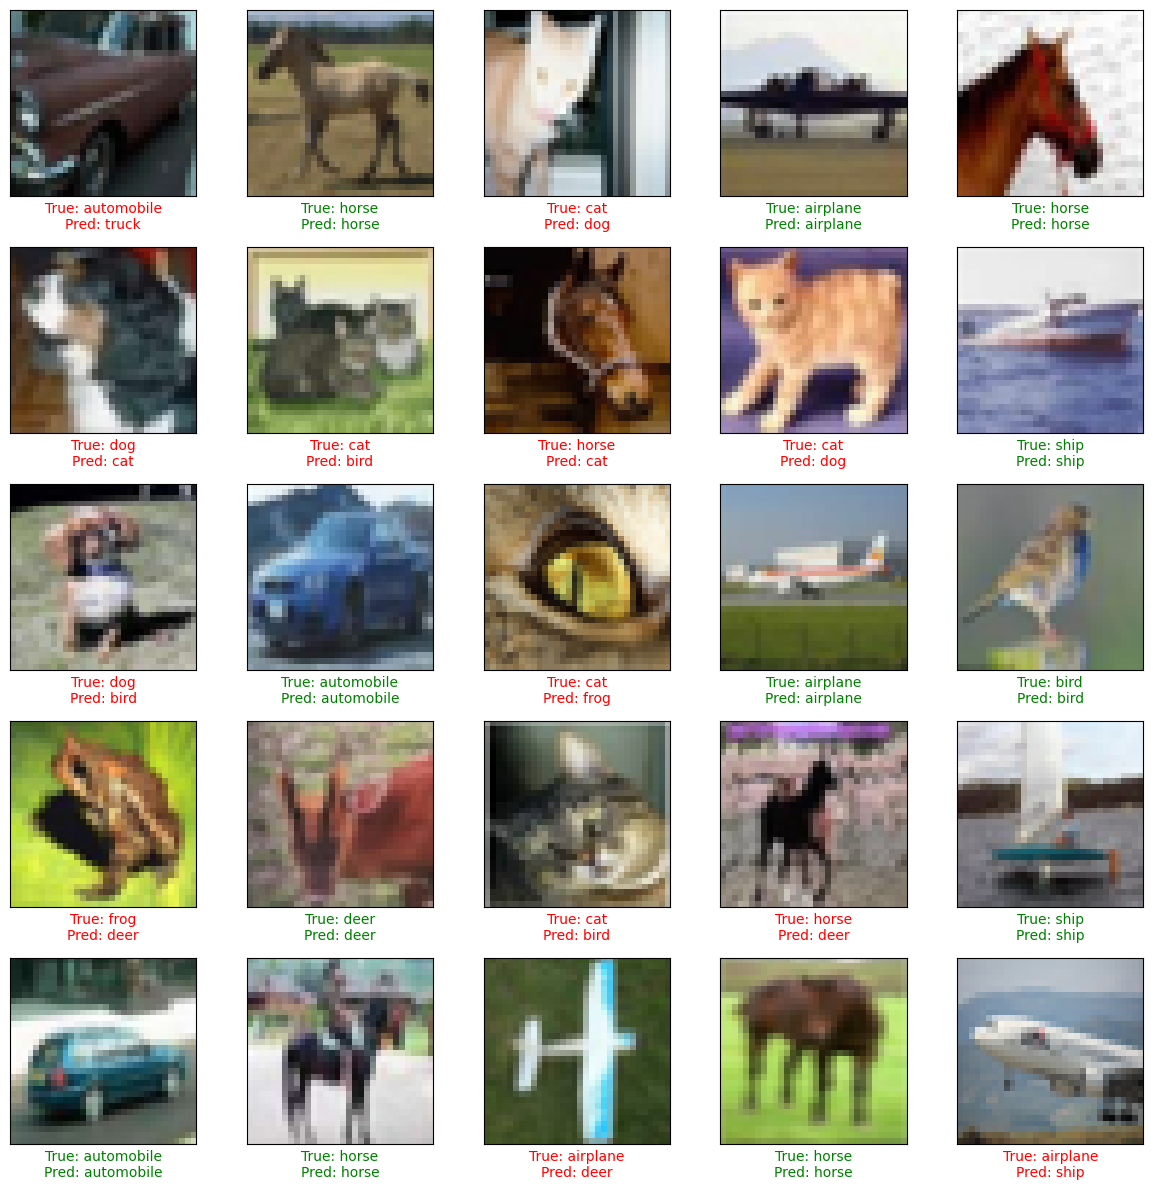

In [ ]:
#visualizing predictions
# 1. Choose the 'Best' model from your tournament (likely Adam)
# Assuming 'model' is your best-performing version
predictions = model.predict(X_test)

# 2. Plot a 5x5 grid of images with True and Predicted labels
plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Show the color image
    plt.imshow(X_test[i])

    true_label = class_names[np.argmax(y_test[i])]
    pred_label = class_names[np.argmax(predictions[i])]

    # Color coding: Green if correct, Red if wrong
    color = 'green' if true_label == pred_label else 'red'

    plt.xlabel(f"True: {true_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()

In [ ]:
#L2 regularization
from keras import regularizers, models, layers

def build_l2_cifar_model(l2_value=0.01):
    model = models.Sequential([
        # Layer 1: Conv + L2
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu',
                      kernel_regularizer=regularizers.l2(l2_value)),
        layers.MaxPooling2D((2, 2)),

        # Layer 2: Conv + L2
        layers.Conv2D(64, (3, 3), activation='relu',
                      kernel_regularizer=regularizers.l2(l2_value)),
        layers.MaxPooling2D((2, 2)),

        # Layer 3: Conv + L2
        layers.Conv2D(64, (3, 3), activation='relu',
                      kernel_regularizer=regularizers.l2(l2_value)),

        # Classifier Head + L2
        layers.Flatten(),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_value)),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Initialize, Compile, and Train
model_l2 = build_l2_cifar_model(l2_value=0.01) # Using professor's 0.01 value

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CIFAR-10 with L2 Regularization...")
history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Training CIFAR-10 with L2 Regularization...
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - accuracy: 0.1628 - loss: 3.4727 - val_accuracy: 0.1971 - val_loss: 2.6723
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2292 - loss: 2.4268 - val_accuracy: 0.2501 - val_loss: 2.2801
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2700 - loss: 2.2210 - val_accuracy: 0.3015 - val_loss: 2.1300
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2888 - loss: 2.1350 - val_accuracy: 0.2363 - val_loss: 2.2633
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3188 - loss: 2.0651 - val_accuracy: 0.3040 - val_loss: 2.0405
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.3420 - loss: 2.0041 - val_accuracy: 0.3224 - val_loss: 2.0542
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3636 - loss: 1.9702 - val_accuracy: 0.2962 - val_loss: 2.0679
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3

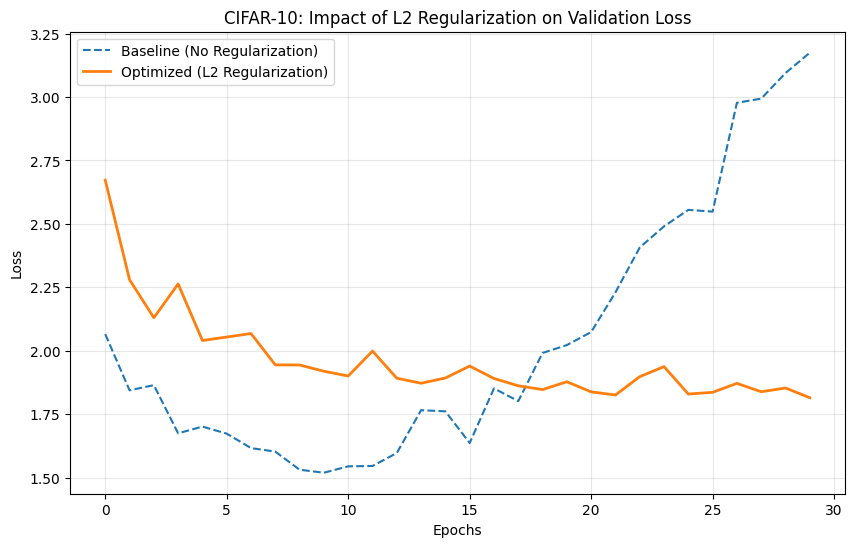

In [ ]:
#visualizing the fix: baseline vs. L2
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_loss'], label='Baseline (No Regularization)', linestyle='--')
plt.plot(history_l2.history['val_loss'], label='Optimized (L2 Regularization)', linewidth=2)

plt.title("CIFAR-10: Impact of L2 Regularization on Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#data augmentation
#setting up augmentation generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the augmentation strategy
datagen = ImageDataGenerator(
    rotation_range=15,      # Rotate images by up to 15 degrees
    width_shift_range=0.1,  # Shift horizontally by 10%
    height_shift_range=0.1, # Shift vertically by 10%
    horizontal_flip=True,   # Flip images horizontally
    zoom_range=0.1          # Randomly zoom in/out by 10%
)

# Compute internal data stats (necessary for some augmentations)
datagen.fit(X_train)

In [ ]:
#train model with augmented data
# Re-build your best model architecture
final_model = build_l2_cifar_model(l2_value=0.001)

final_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train using the 'flow' method to generate images on the fly
history_augmented = final_model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=50, # Augmentation usually requires more epochs to converge
    validation_data=(X_val, y_val),
    steps_per_epoch=len(X_train) // 64
)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - accuracy: 0.1363 - loss: 2.4577 - val_accuracy: 0.1920 - val_loss: 2.3499
Epoch 2/50
 1/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1562 - loss: 2.3679

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.1562 - loss: 2.3679 - val_accuracy: 0.1917 - val_loss: 2.3350
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.2065 - loss: 2.2234 - val_accuracy: 0.2175 - val_loss: 2.1572
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.2031 - loss: 2.1971 - val_accuracy: 0.2169 - val_loss: 2.1622
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.2759 - loss: 2.0455 - val_accuracy: 0.2956 - val_loss: 2.0104
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.3125 - loss: 1.8916 - val_accuracy: 0.2790 - val_loss: 2.0804
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.3103 - loss: 1.9784 - val_accuracy: 0.3292 - val_loss: 1.9094
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.4062 - loss: 1.8910 - val_accuracy: 0.3177 - val_loss: 1.9286
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.3206 - loss: 1.9235 - val_accuracy: 0.3551 - val_loss: 1

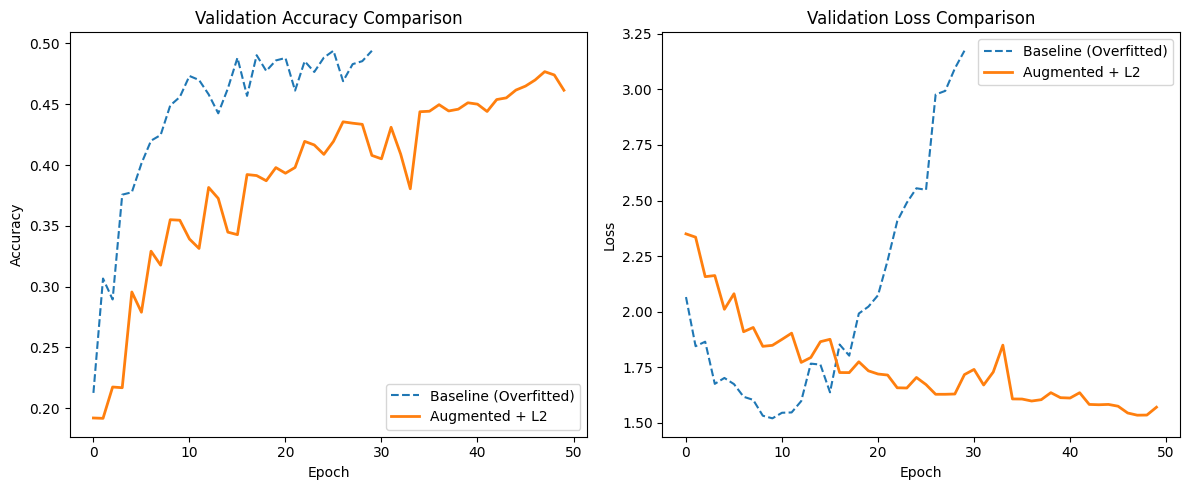

In [ ]:
#visualizing the fix: baseline vs. augmentation
plt.figure(figsize=(12, 5))

# Plot Accuracy comparison
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (Overfitted)', linestyle='--')
plt.plot(history_augmented.history['val_accuracy'], label='Augmented + L2', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss comparison
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_loss'], label='Baseline (Overfitted)', linestyle='--')
plt.plot(history_augmented.history['val_loss'], label='Augmented + L2', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#early stopping
from tensorflow.keras.callbacks import EarlyStopping

# 1. Setup Early Stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',   # Watch the validation accuracy
    patience=5,               # Give it 5 epochs to improve before quitting
    restore_best_weights=True # Make sure we keep the best version of the model
)

# 2. Build and Compile
model_es = build_l2_cifar_model(l2_value=0.001)
model_es.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train (We can set epochs high, like 100, because Early Stopping will handle it)
print("Training with Early Stopping...")
history_es = model_es.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Training with Early Stopping...
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.1224 - loss: 2.4294 - val_accuracy: 0.1647 - val_loss: 2.2642
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.2304 - loss: 2.1537 - val_accuracy: 0.2361 - val_loss: 2.1548
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2840 - loss: 2.0421 - val_accuracy: 0.2327 - val_loss: 2.1769
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2984 - loss: 1.9571 - val_accuracy: 0.2823 - val_loss: 2.0937
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3276 - loss: 1.9405 - val_accuracy: 0.3088 - val_loss: 1.9438
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.3596 - loss: 1.8308 - val_accuracy: 0.3541 - val_loss: 1.8272
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3908 - loss: 1.7500 - val_accuracy: 0.3651 - val_loss: 1.8094
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3992 

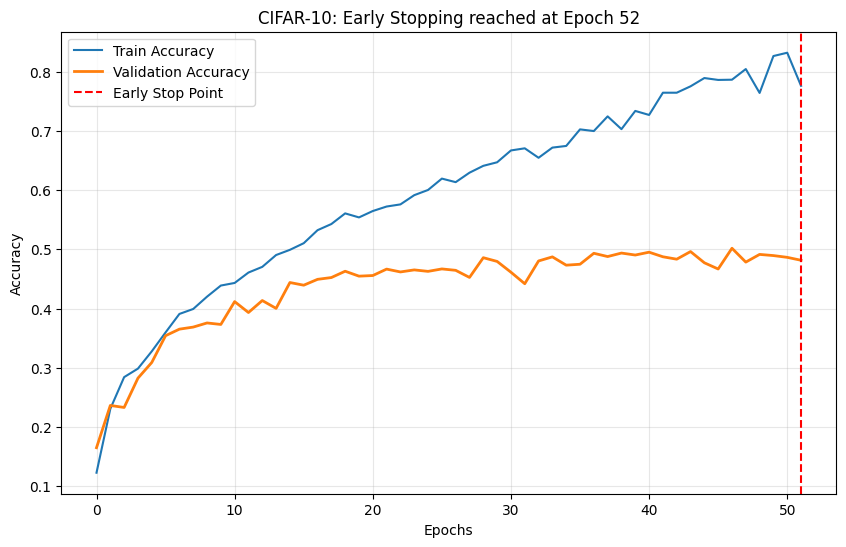

In [ ]:
#visualizing stop point
plt.figure(figsize=(10, 6))
plt.plot(history_es.history['accuracy'], label='Train Accuracy')
plt.plot(history_es.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

# Find the epoch where it stopped
stopped_epoch = len(history_es.history['accuracy'])
plt.axvline(x=stopped_epoch-1, color='r', linestyle='--', label='Early Stop Point')

plt.title(f"CIFAR-10: Early Stopping reached at Epoch {stopped_epoch}")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#cifar-10 with dropout layers
#build, train dropout modelfrom keras import models, layers

def build_dropout_cifar_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Conv Blocks
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        # Classifier Head with Dropout
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),  # 🔹 Dropout added (30%)

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),  # 🔹 Dropout added (30%)

        layers.Dense(10, activation='softmax')
    ])
    return model

# Compile and Train
model_dropout = build_dropout_cifar_model()
model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training CIFAR-10 with Dropout...")
history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Training CIFAR-10 with Dropout...
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 0.1256 - loss: 2.2890 - val_accuracy: 0.2087 - val_loss: 2.1977
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1992 - loss: 2.1527 - val_accuracy: 0.2984 - val_loss: 2.0120
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2452 - loss: 2.0431 - val_accuracy: 0.3149 - val_loss: 1.9096
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3100 - loss: 1.8571 - val_accuracy: 0.3645 - val_loss: 1.7815
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.3464 - loss: 1.7604 - val_accuracy: 0.3884 - val_loss: 1.6698
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3768 - loss: 1.7052 - val_accuracy: 0.4056 - val_loss: 1.6493
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4020 - loss: 1.6313 - val_accuracy: 0.4065 - val_loss: 1.6257
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4364 - loss

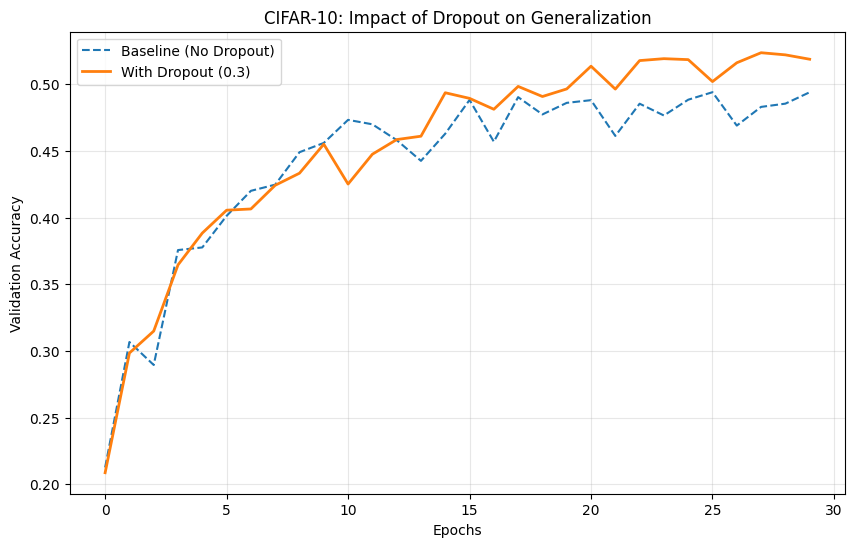

In [ ]:
#visualizing smoothing effect
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['val_accuracy'], label='Baseline (No Dropout)', linestyle='--')
plt.plot(history_dropout.history['val_accuracy'], label='With Dropout (0.3)', linewidth=2)

plt.title("CIFAR-10: Impact of Dropout on Generalization")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#adding noise
import numpy as np

# --- 1. Add Input Noise (Gaussian Noise) ---
noise_factor = 0.1
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_train_noisy = np.clip(X_train_noisy, 0., 1.) # Keep pixels in [0, 1] range

# --- 2. Add Output Noise (Label Flipping) ---
# Randomly flip 10% of the training labels
y_train_noisy = y_train.copy()
noise_ratio = 0.1
num_samples = int(noise_ratio * y_train_noisy.shape[0])
random_indices = np.random.choice(y_train_noisy.shape[0], num_samples, replace=False)

for idx in random_indices:
    random_label = np.random.randint(0, 10)
    # Convert back to one-hot for consistency
    y_train_noisy[idx] = keras.utils.to_categorical(random_label, 10)

print(f"Applied Gaussian noise and flipped {num_samples} labels.")

Applied Gaussian noise and flipped 250 labels.


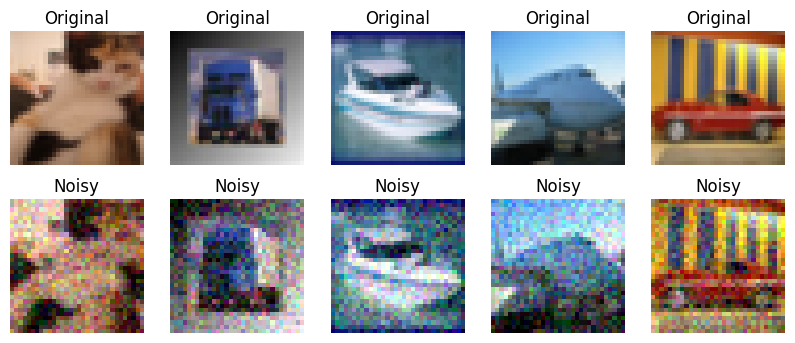

In [ ]:
#visualize
plt.figure(figsize=(10, 4))
for i in range(5):
    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(2, 5, i + 6)
    plt.imshow(X_train_noisy[i])
    plt.title("Noisy")
    plt.axis('off')
plt.show()

In [ ]:
#training and analyzing noise robustness
# Build the model (using your best architecture)
model_noisy = build_l2_cifar_model(l2_value=0.001)

model_noisy.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train on Noisy Input and Noisy Labels
history_noisy = model_noisy.fit(
    X_train_noisy, y_train_noisy,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val) # Validate on CLEAN data to see true performance
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - accuracy: 0.1268 - loss: 2.4481 - val_accuracy: 0.1857 - val_loss: 2.3317
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.1848 - loss: 2.2600 - val_accuracy: 0.1921 - val_loss: 2.2001
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2664 - loss: 2.1039 - val_accuracy: 0.2818 - val_loss: 1.9925
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3072 - loss: 2.0185 - val_accuracy: 0.2937 - val_loss: 1.9940
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3152 - loss: 1.9807 - val_accuracy: 0.2819 - val_loss: 2.0115
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3348 - loss: 1.9210 - val_accuracy: 0.2918 - val_loss: 1.9845
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3420 - loss: 1.9020 - val_accuracy: 0.3679 - val_loss: 1.8098
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3712 - loss: 1.8483 - val_accuracy: 0.3400 - 

In [ ]:
#parameter sharing

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate
from tensorflow.keras.models import Model

# 1. Define the Shared "Feature Extractor"
shared_conv = Conv2D(32, (3, 3), activation='relu')
shared_pool = MaxPooling2D((2, 2))

# 2. Define Two Separate Inputs (e.g., looking at two different crops of an image)
input_a = Input(shape=(32, 32, 3))
input_b = Input(shape=(32, 32, 3))

# 3. Apply the SAME layers to both (Sharing Parameters)
feat_a = shared_pool(shared_conv(input_a))
feat_b = shared_pool(shared_conv(input_b))

# 4. Merge the features
merged = Concatenate()([Flatten()(feat_a), Flatten()(feat_b)])
dense_out = Dense(64, activation='relu')(merged)
output = Dense(10, activation='softmax')(dense_out)

# 5. Build Model
model_shared = Model(inputs=[input_a, input_b], outputs=output)
model_shared.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# For demo: feeding the same image twice
model_shared.fit([X_train, X_train], y_train, epochs=5, batch_size=64)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.1956 - loss: 2.1850
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3236 - loss: 1.8944
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3940 - loss: 1.6886
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4524 - loss: 1.5633
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5104 - loss: 1.4153


In [ ]:
# ensemble code

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate
from tensorflow.keras.models import Model

# 1. Define the Shared "Feature Extractor"
shared_conv = Conv2D(32, (3, 3), activation='relu')
shared_pool = MaxPooling2D((2, 2))

# 2. Define Two Separate Inputs (e.g., looking at two different crops of an image)
input_a = Input(shape=(32, 32, 3))
input_b = Input(shape=(32, 32, 3))

# 3. Apply the SAME layers to both (Sharing Parameters)
feat_a = shared_pool(shared_conv(input_a))
feat_b = shared_pool(shared_conv(input_b))

# 4. Merge the features
merged = Concatenate()([Flatten()(feat_a), Flatten()(feat_b)])
dense_out = Dense(64, activation='relu')(merged)
output = Dense(10, activation='softmax')(dense_out)

# 5. Build Model
model_shared = Model(inputs=[input_a, input_b], outputs=output)
model_shared.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# For demo: feeding the same image twice
model_shared.fit([X_train, X_train], y_train, epochs=5, batch_size=64)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.1884 - loss: 2.2222
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2728 - loss: 1.9465
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3668 - loss: 1.7539
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4060 - loss: 1.6274
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4780 - loss: 1.5042


In [ ]:
# 1. Install the necessary drawing engines for Colab
!apt-get install -y graphviz libgraphviz-dev
!pip install pydot graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 42 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http:

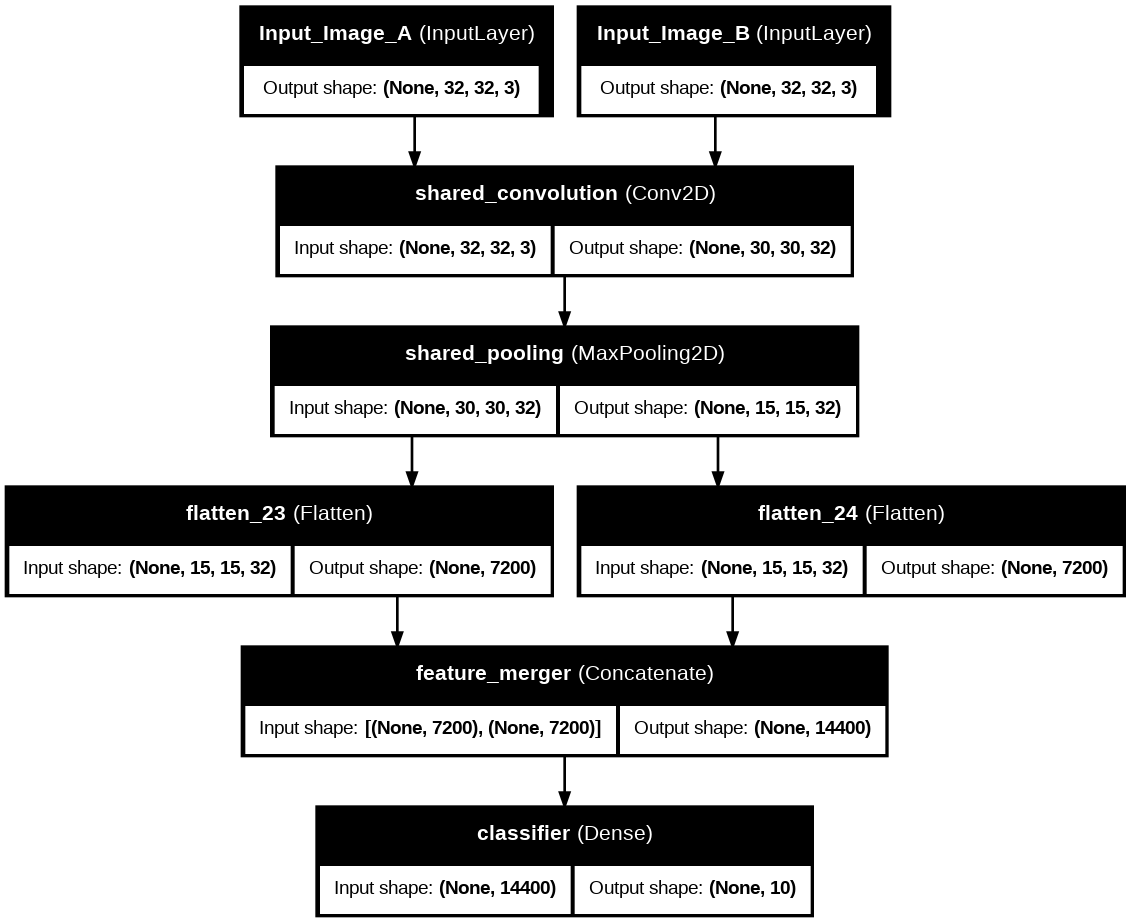

✅ Model architecture successfully plotted!


In [ ]:
# visualizing the functional architecture

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from IPython.display import Image
import pydot

# --- Step 1: Define the Shared Architecture ---
# We define these once so both inputs "share" the same weights (eyes)
shared_conv = Conv2D(32, (3, 3), activation='relu', name="shared_convolution")
shared_pool = MaxPooling2D((2, 2), name="shared_pooling")

# --- Step 2: Define Two Separate Inputs (CIFAR-10 Shape: 32, 32, 3) ---
input_a = Input(shape=(32, 32, 3), name="Input_Image_A")
input_b = Input(shape=(32, 32, 3), name="Input_Image_B")

# --- Step 3: Pass both inputs through the SAME layers ---
feat_a = shared_pool(shared_conv(input_a))
feat_b = shared_pool(shared_conv(input_b))

# --- Step 4: Merge and Classify ---
# Flatten the 2D features into 1D vectors
flat_a = Flatten()(feat_a)
flat_b = Flatten()(feat_b)

# Concatenate (Stitch) them together side-by-side
merged = Concatenate(name="feature_merger")([flat_a, flat_b])

# Final output layer for 10 CIFAR classes
output = Dense(10, activation='softmax', name="classifier")(merged)

# Define the multi-input model
model_shared = Model(inputs=[input_a, input_b], outputs=output)

# --- Step 5: Plot and Display ---
try:
    # This creates the file 'model_shared_plot.png' in your Colab sidebar
    plot_model(model_shared,
               to_file='model_shared_plot.png',
               show_shapes=True,
               show_layer_names=True,
               expand_nested=True,
               dpi=96)

    # Display the generated image in the notebook
    display(Image(filename='model_shared_plot.png'))
    print("✅ Model architecture successfully plotted!")
except Exception as e:
    print(f"❌ Plotting failed: {e}")
    print("\nAlternative: Showing text summary instead:")
    model_shared.summary()

In [ ]:
# final ensemble comparison table

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, datasets
from sklearn.model_selection import train_test_split

# 1. RELOAD DATA (Fixes the NameError)
(X_train_full, y_train_full), (X_test_full, y_test_full) = datasets.cifar10.load_data()

# Normalize
X_train_full = X_train_full.astype('float32') / 255.0
X_test_full = X_test_full.astype('float32') / 255.0

# Re-create the 5% split to match your previous experiments
X_train, X_temp, y_train, y_temp = train_test_split(
    X_train_full, y_train_full, test_size=0.95, stratify=y_train_full, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# 2. DEFINE ARCHITECTURES
def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_l2_cifar_model(l2_value=0.001):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_value)),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_value)),
        layers.Dense(10, activation='softmax')
    ])
    return model

def build_dropout_cifar_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    return model

# 3. TRAIN MODELS
print("Training Ensemble Models... Please wait.")
model1 = build_baseline_model()
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)

model2 = build_l2_cifar_model()
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model2.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)

model3 = build_dropout_cifar_model()
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model3.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)

# 4. ENSEMBLE VOTING
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

ensemble_probs = (pred1 + pred2 + pred3) / 3
ensemble_classes = np.argmax(ensemble_probs, axis=1)
true_classes = np.argmax(y_test, axis=1)
ensemble_acc = np.mean(ensemble_classes == true_classes)

# 5. FINAL TABLE
results_data = {
    "Model Configuration": ["Model 1 (Baseline)", "Model 2 (L2 Regularization)", "Model 3 (Dropout)", "Final Ensemble (Soft Voting)"],
    "Test Accuracy": [
        f"{model1.evaluate(X_test, y_test, verbose=0)[1]:.4f}",
        f"{model2.evaluate(X_test, y_test, verbose=0)[1]:.4f}",
        f"{model3.evaluate(X_test, y_test, verbose=0)[1]:.4f}",
        f"{ensemble_acc:.4f}"
    ]
}

print("\n--- Final Project Performance Summary ---")
print(pd.DataFrame(results_data))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training Ensemble Models... Please wait.
743/743 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

--- Final Project Performance Summary ---
            Model Configuration Test Accuracy
0            Model 1 (Baseline)        0.4517
1   Model 2 (L2 Regularization)        0.4351
2             Model 3 (Dropout)        0.4596
3  Final Ensemble (Soft Voting)        0.4696


743/743 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
743/743 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
743/743 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


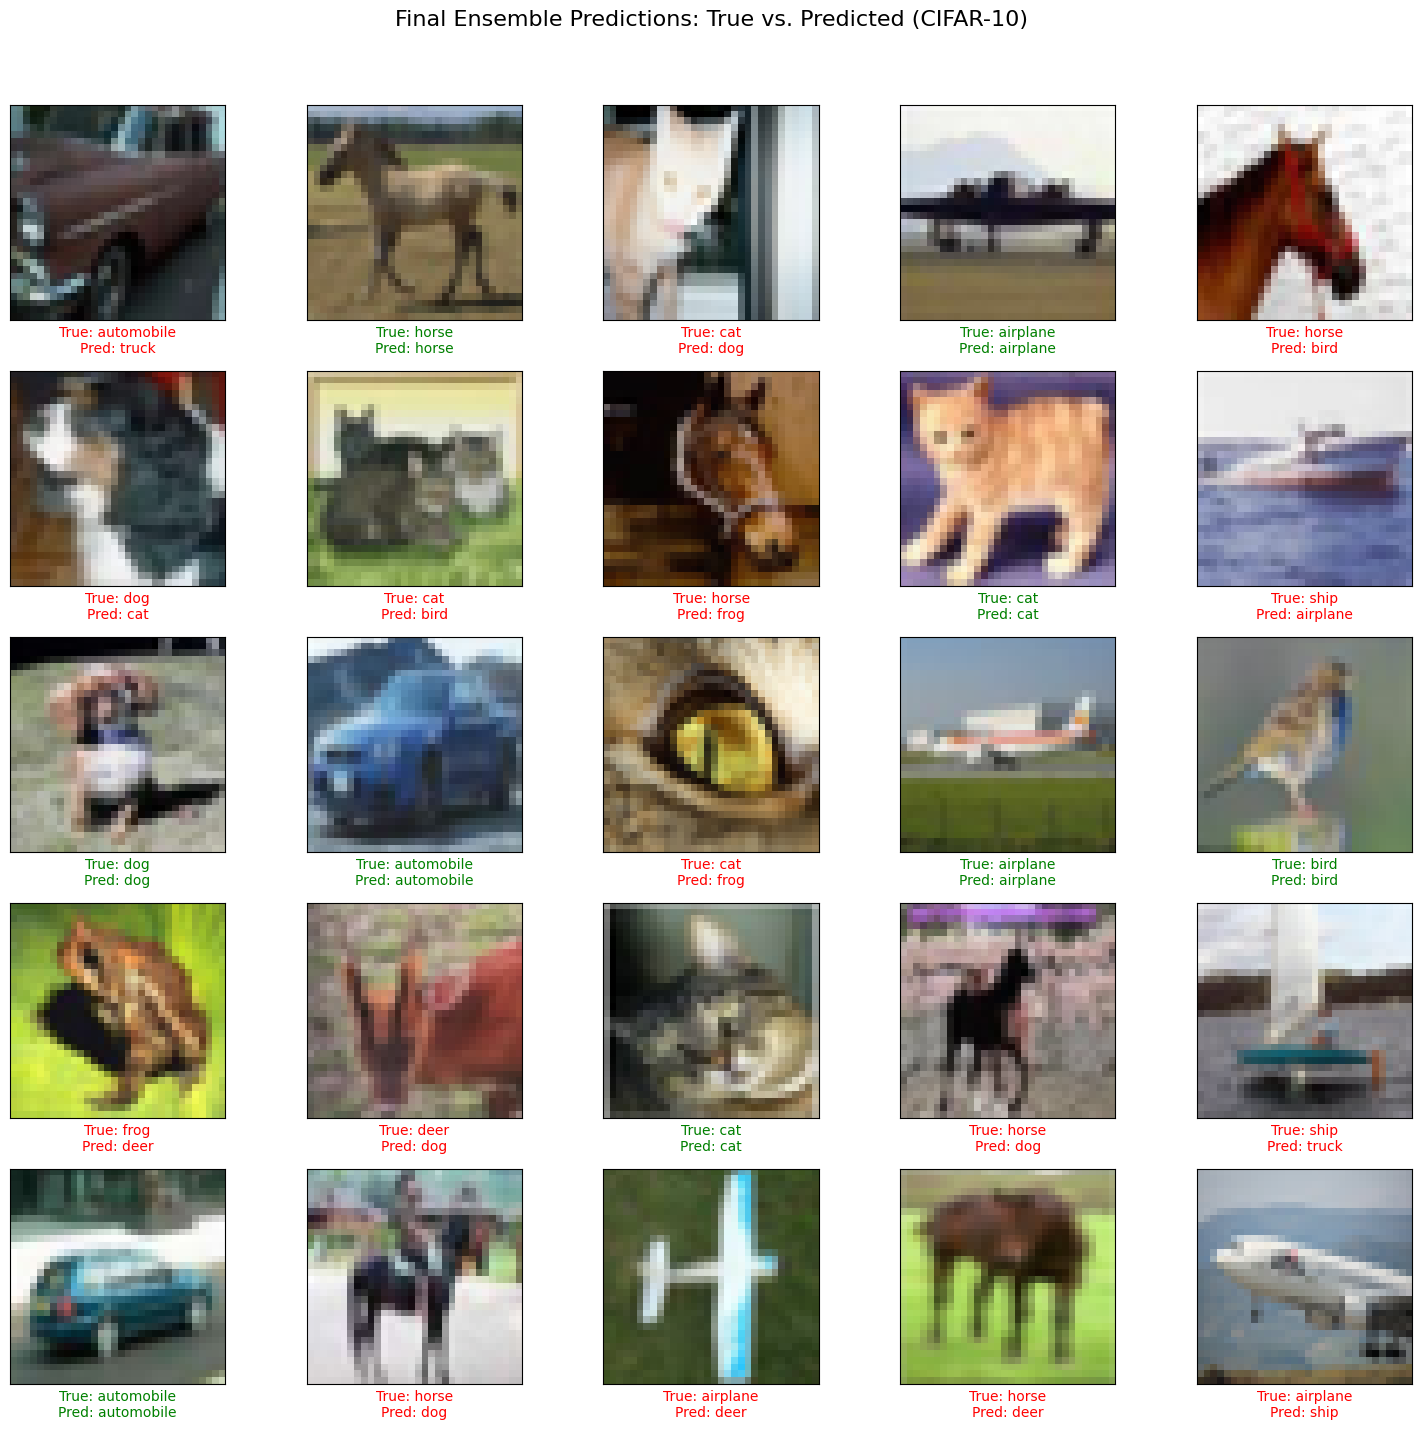

In [ ]:
# final 25 image prediction grid

import numpy as np
import matplotlib.pyplot as plt

# 1. Ensure class names are defined for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Re-calculate predictions to ensure variables are in memory
# This uses the three models (model1, model2, model3) we just trained
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

# 3. Compute the Soft Voting Ensemble probabilities
ensemble_probs = (pred1 + pred2 + pred3) / 3
ensemble_classes = np.argmax(ensemble_probs, axis=1)
true_classes = np.argmax(y_test, axis=1)

# 4. Plot the 5x5 Grid (Visualizing the first 25 test images)
plt.figure(figsize=(15, 15))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the actual color image from the test set
    plt.imshow(X_test[i])

    true_label = class_names[true_classes[i]]
    pred_label = class_names[ensemble_classes[i]]

    # Visual feedback: Green for correct, Red for mistakes
    color = 'green' if true_label == pred_label else 'red'

    plt.xlabel(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)

plt.suptitle("Final Ensemble Predictions: True vs. Predicted (CIFAR-10)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# CNN implementation

import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.utils import to_categorical

# 1. Loading the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# 2. Preprocessing
# CIFAR-10 images are 32x32 pixels with 3 color channels (RGB)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 3. One-hot encoding for 10 classes
n_classes = 10
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)

# 4. Building the Model (Following your professor's architecture)
model = Sequential()

# Convolutional Layer: Adjusted input_shape to (32, 32, 3)
model.add(Conv2D(25, kernel_size=(3,3), strides=(1,1), padding='valid',
                 activation='relu', input_shape=(32, 32, 3)))

# Pooling Layer (Matching your professor's pool_size=1,1)
model.add(MaxPool2D(pool_size=(1,1)))

# Flattening the 3D output to 1D
model.add(Flatten())

# Hidden Layer
model.add(Dense(100, activation='relu'))

# Output Layer
model.add(Dense(n_classes, activation='softmax'))

# 5. Compiling the model
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

# 6. Training the model
# Using batch_size=128 and 10 epochs as per the example
print("Training CIFAR-10 model...")
history = model.fit(X_train, Y_train, batch_size=128, epochs=10,
                    validation_data=(X_test, Y_test))

# 7. Final Evaluation
scores = model.evaluate(X_test, Y_test, verbose=0)
print(f"CIFAR-10 Test accuracy: {scores[1]*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CIFAR-10 model...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4355 - loss: 1.5882 - val_accuracy: 0.5102 - val_loss: 1.3677
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5557 - loss: 1.2625 - val_accuracy: 0.5518 - val_loss: 1.2555
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6067 - loss: 1.1290 - val_accuracy: 0.5844 - val_loss: 1.1895
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6375 - loss: 1.0427 - val_accuracy: 0.5892 - val_loss: 1.1600
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6664 - loss: 0.9590 - val_accuracy: 0.6041 - val_loss: 1.1266
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6896 - loss: 0.8897 - val_accuracy: 0.6123 - val_loss: 1.1243
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7136 - loss: 0.8291 - val_accuracy: 0.6124 - val_loss: 1.1297
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7362 - los

In [ ]:
# final evaluation

from sklearn.metrics import accuracy_score
import numpy as np

# 1. Evaluating the model using the Keras built-in method
test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# 2. Making predictions on the CIFAR-10 test set
y_pred = model.predict(X_test)

# 3. Convert predictions from one-hot encoding back to class labels
# argmax(axis=-1) finds the index (0-9) with the highest probability
y_pred_classes = np.argmax(y_pred, axis=-1)

# 4. Convert Y_test (One-Hot) back to class labels for comparison
y_test_classes = np.argmax(Y_test, axis=-1)

# 5. Calculating accuracy using sklearn's accuracy_score
# This should match the test_acc from model.evaluate()
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print(f"Accuracy Score (sklearn): {accuracy:.4f}")

Test loss: 1.1835
Test accuracy: 0.6065
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy Score (sklearn): 0.6065


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 42 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http:

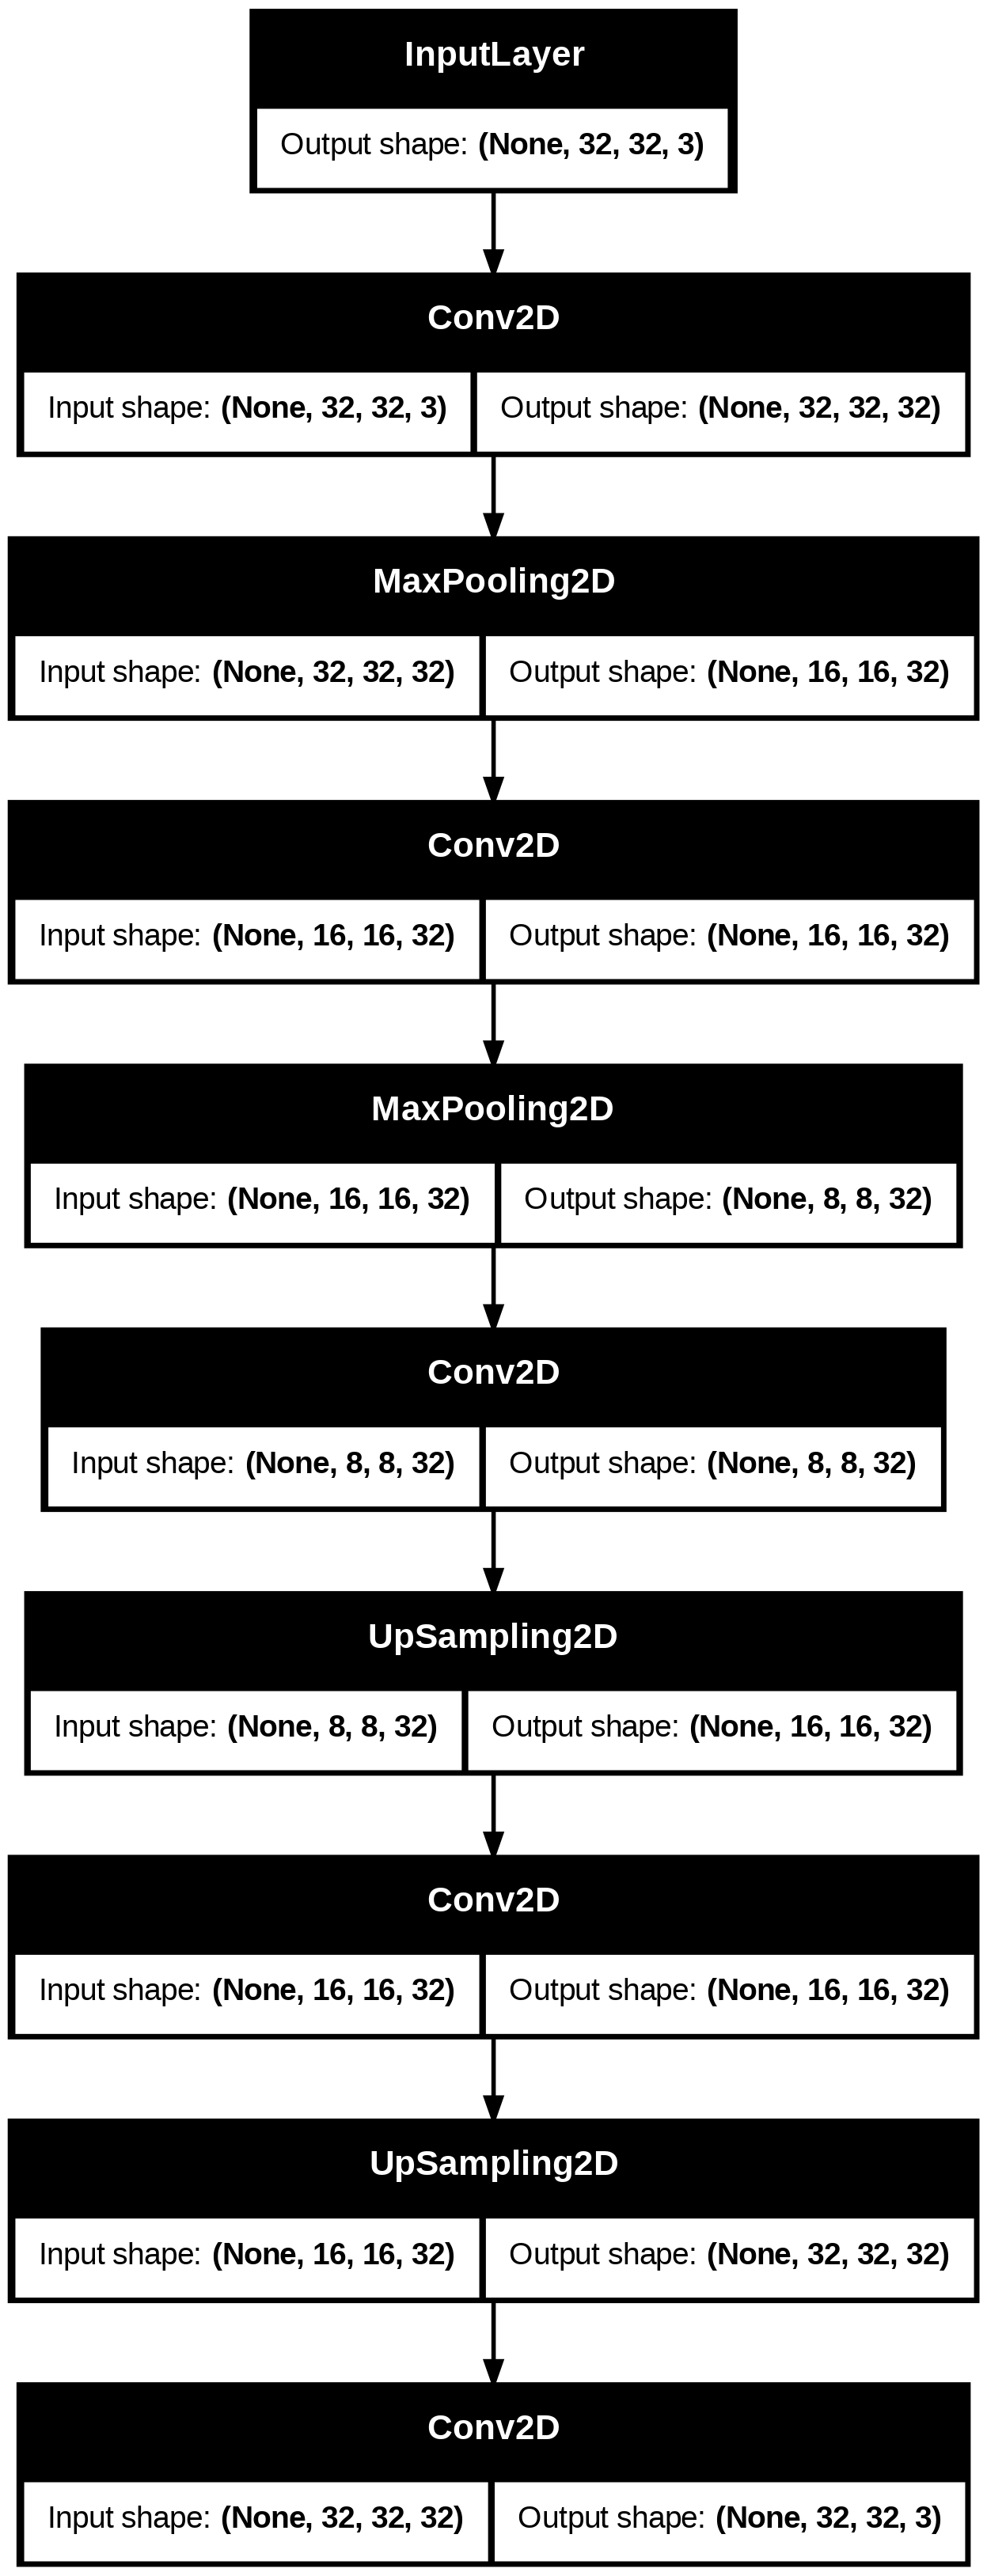

--- Starting Training (10 Epochs) ---
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.5803 - val_loss: 0.5672
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5649 - val_loss: 0.5643
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5629 - val_loss: 0.5629
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.5620 - val_loss: 0.5627
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5613 - val_loss: 0.5623
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.5606 - val_loss: 0.5611
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.5602 - val_loss: 0.5607
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5600 - val_loss: 0.5604
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5595 - val_loss: 0.5630
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.5593 - val_loss: 0.5598
--- Evaluating Final Performance ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5598

Fi

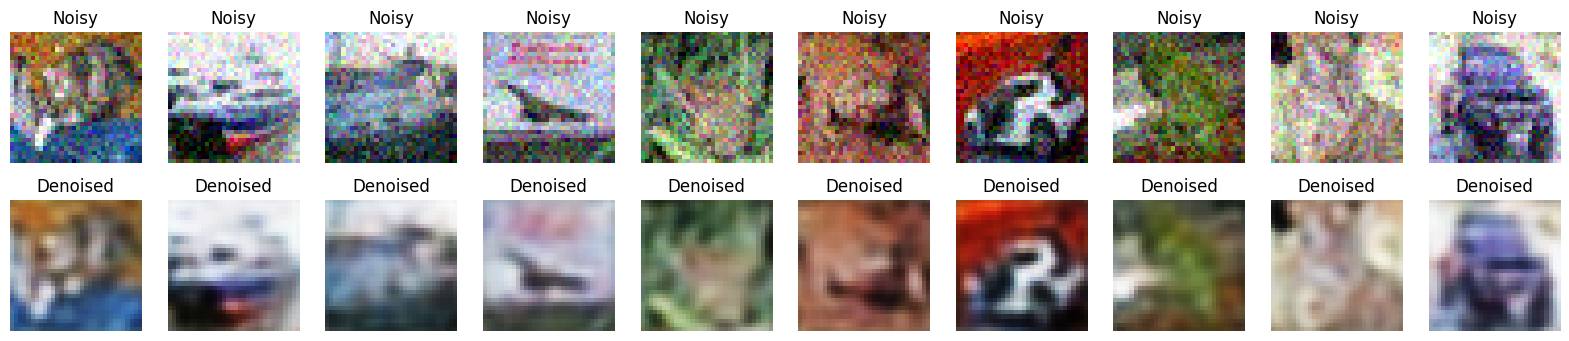

In [ ]:
# 1. Install system dependencies for plotting (Run this first if plot_model fails)
!apt-get install -y graphviz libgraphviz-dev
!pip install pydot graphviz

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, datasets, models
import numpy as np
import matplotlib.pyplot as plt
import os

# 2. Load and Preprocess CIFAR-10
print("--- Loading and Preprocessing Data ---")
(x_train, _), (x_test, _) = datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add Noise for the Denoising Task
noise_factor = 0.1
x_train_noisy = np.clip(x_train + noise_factor * np.random.normal(0, 1, x_train.shape), 0., 1.)
x_test_noisy = np.clip(x_test + noise_factor * np.random.normal(0, 1, x_test.shape), 0., 1.)

# 3. Build Convolutional Denoising Autoencoder
print("--- Building Model Architecture ---")
input_img = layers.Input(shape=(32, 32, 3))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
# Final layer: 3 filters for RGB
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Visualize Architecture (Functional API)
try:
    keras.utils.plot_model(autoencoder, to_file='model_plot.png', show_shapes=True)
    from IPython.display import Image
    display(Image(filename='model_plot.png'))
except:
    print("Plotting failed, skipping to training...")

# 5. Train the Model
print("--- Starting Training (10 Epochs) ---")
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

# 6. Evaluate and Visualize Results
print("--- Evaluating Final Performance ---")
score = autoencoder.evaluate(x_test_noisy, x_test, verbose=1)
print(f'\nFinal Reconstruction Loss: {score}')

# Visual comparison
decoded_imgs = autoencoder.predict(x_test_noisy)
decoded_imgs = np.clip(decoded_imgs.astype('float32'), 0, 1)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Noisy
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis('off')
    # Denoised
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Denoised")
    plt.axis('off')
plt.show()

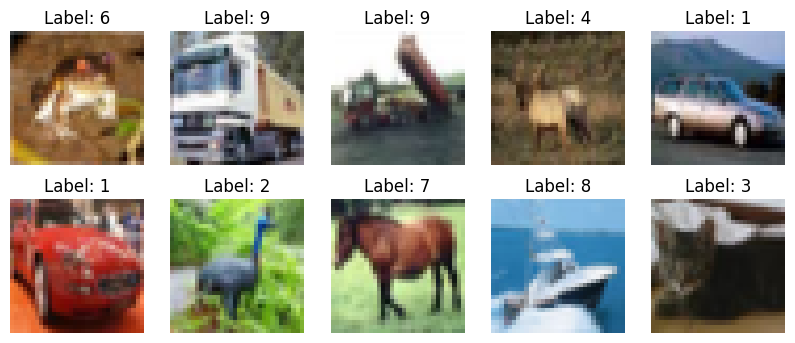

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3444 - loss: 1.8368 - val_accuracy: 0.3735 - val_loss: 1.7722
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4122 - loss: 1.6581 - val_accuracy: 0.4273 - val_loss: 1.6211
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4498 - loss: 1.5447 - val_accuracy: 0.4446 - val_loss: 1.5343
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4780 - loss: 1.4632 - val_accuracy: 0.4789 - val_loss: 1.4681
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5013 - loss: 1.3973 - val_accuracy: 0.4918 - val_loss: 1.4304
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5236 - loss: 1.3429 - val_accuracy: 0.5064 - val_loss: 1.3947
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5375 - loss: 1.2951 - val_accuracy: 0.5194 - val_loss: 1.3653
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5543 - loss: 1.2515 - val_accuracy: 0

In [ ]:
# LeNet-5 CNN Architecture

import keras
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# 1. Load CIFAR-10 Dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# 2. Visualize Training Data (MNIST-Style)
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i]) # CIFAR-10 is color, no cmap='gray' needed
    plt.title(f"Label: {y_train[i][0]}")
    plt.axis('off')
plt.show()

# 3. Data Processing & Splitting
# Using the same 50k/10k split as your professor
x_train_main = x_train[:40000] # Adjusting split to ensure val set is from train
y_train_main = y_train[:40000]
x_val = x_train[40000:]
y_val = y_train[40000:]

# 4. Normalize and Reshape
# CIFAR-10 is already (Samples, 32, 32, 3), so we just scale pixels
x_train_main = x_train_main / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# 5. One Hot Encoding
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# 6. Build LeNet-5 Model (Adjusted for CIFAR-10)
LeNet5_Model = Sequential()

# First Conv Layer: Adjusted input_shape to (32, 32, 3)
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 3)))
LeNet5_Model.add(AveragePooling2D((2, 2)))

LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))
LeNet5_Model.add(AveragePooling2D((2, 2)))

LeNet5_Model.add(Flatten())

LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))

# 7. Compile, Summary, and Train
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
LeNet5_Model.summary()

LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))

# 8. Evaluate
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('CIFAR-10 LeNet-5 Test accuracy:', test_acc)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,767,882 (94.48 MB)

 Trainable params: 24,767,882 (94.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 49s 11ms/step - accuracy: 0.0993 - loss: 2.3034 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.0968 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.0969 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.0984 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.0973 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3026


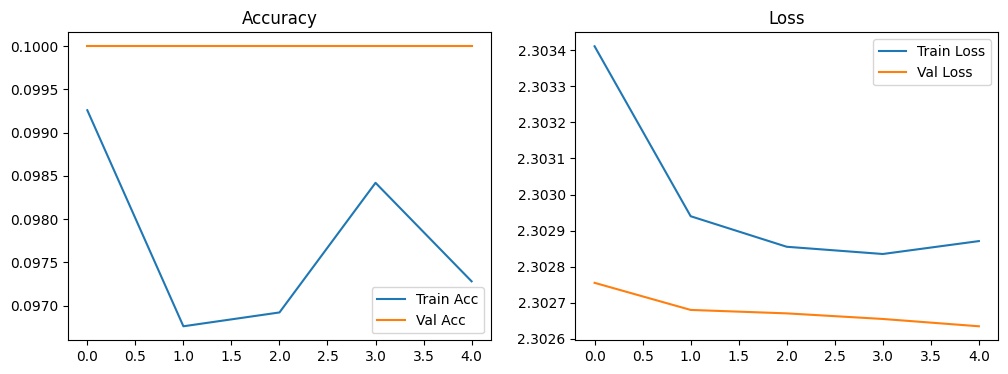

13637

In [ ]:
# AlexNet CNN Architecture

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

# 1. Clear session and set mixed precision for memory efficiency
keras.backend.clear_session()
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# 2. Load CIFAR-10 Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# 3. Preprocess Pipeline (Simplified for CIFAR color images)
def process_image(image, label):
    # Resize 32x32 to 112x112 as per the MNIST experiment logic
    image = tf.image.resize(image, (112, 112))
    return image / 255.0, tf.one_hot(tf.squeeze(label), 10)

# 4. Create Dataset Pipelines (Using batch size 16 for better stability on CIFAR)
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(process_image).batch(16).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(process_image).batch(16).prefetch(tf.data.AUTOTUNE)

# 5. Build AlexNet Model (112x112 Input)
model = Sequential([
    # Layer 1: Conv + MaxPool
    Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(112, 112, 3)),
    MaxPooling2D((3, 3), strides=(2, 2)),

    # Layer 2: Conv + MaxPool
    Conv2D(256, (5, 5), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=(2, 2)),

    # Layers 3-5: Convolutional sequence
    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(384, (3, 3), padding='same', activation='relu'),
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=(2, 2)),

    # Flatten + Fully Connected
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
])

# 6. Compile and Summary
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# 7. Train
history = model.fit(train_ds, epochs=5, validation_data=test_ds)

# 8. Visualizing Results (MNIST Style)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

gc.collect()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Now your model definition will work:
model_zf = Sequential([
    # Layer 1: Smaller 7x7 filters for better detail (ZFNet improvement over AlexNet)
    Conv2D(96, (7, 7), strides=(2, 2), activation='relu', input_shape=(32, 32, 3), padding='same'),
    MaxPooling2D((3, 3), strides=(2, 2), padding='same'),

    # Layer 2: 5x5 filters
    Conv2D(256, (5, 5), strides=(2, 2), activation='relu', padding='same'),
    MaxPooling2D((3, 3), strides=(2, 2), padding='same'),

    # Layers 3-5: Similar to AlexNet
    Conv2D(384, (3, 3), activation='relu', padding='same'),
    Conv2D(384, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((3, 3), strides=(2, 2), padding='same'),

    Flatten(),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_zf.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 96)     │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 2, 2, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 2, 2, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,999,882 (15.26 MB)

 Trainable params: 3,999,882 (15.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# VGG-16 CN Architecture

model_vgg = Sequential([
    # Block 1
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2), strides=(2, 2)),

    # Block 2
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2), strides=(2, 2)),

    # Block 3
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2), strides=(2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [ ]:
# GoogLeNet CN Architecture

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Concatenate, Flatten, Dense
from tensorflow.keras.models import Model

def inception_module(x, filters):
    # Branch 1: 1x1 Conv
    path1 = Conv2D(filters[0], (1, 1), padding='same', activation='relu')(x)

    # Branch 2: 1x1 Conv -> 3x3 Conv
    path2 = Conv2D(filters[1], (1, 1), padding='same', activation='relu')(x)
    path2 = Conv2D(filters[2], (3, 3), padding='same', activation='relu')(path2)

    # Branch 3: 1x1 Conv -> 5x5 Conv
    path3 = Conv2D(filters[3], (1, 1), padding='same', activation='relu')(x)
    path3 = Conv2D(filters[4], (5, 5), padding='same', activation='relu')(path3)

    # Branch 4: MaxPool -> 1x1 Conv
    path4 = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    path4 = Conv2D(filters[5], (1, 1), padding='same', activation='relu')(path4)

    return Concatenate(axis=-1)([path1, path2, path3, path4])

# Build Mini-GoogLeNet for 32x32 CIFAR-10
input_img = Input(shape=(32, 32, 3))
x = Conv2D(64, (3, 3), padding='same', activation='relu')(input_img)
x = inception_module(x, [32, 32, 32, 8, 16, 16])
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
output = Dense(10, activation='softmax')(x)

model_googlenet = Model(inputs=input_img, outputs=output)
model_googlenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_googlenet.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 32,    │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │      2,080 │ conv2d_16[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32, 8) │        520 │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 32, 32,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │      2,080 │ conv2d_16[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │      9,248 │ conv2d_18[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 32, 32,    │      3,216 │ conv2d_20[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │      1,040 │ max_pooling2d_8[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_17[0][0],  │
│ (Concatenate)       │ 96)               │            │ conv2d_19[0][0],  │
│                     │                   │            │ conv2d_21[0][0],  │
│                     │                   │            │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 16, 16,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 24576)     │          0 │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │    245,770 │ flatten_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 265,746 (1.01 MB)

 Trainable params: 265,746 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, add
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10

# 1. Load and Preprocess Data (Ensures no NameErrors for X_train/y_train)
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 2. Define the Residual Block correctly using the 'layers' module
def residual_block(x, filters):
    shortcut = x
    # First Conv
    x = Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    # Second Conv (No activation yet)
    x = Conv2D(filters, (3, 3), padding='same')(x)

    # Add the shortcut (The "Skip Connection")
    x = add([x, shortcut])
    # Use layers.Activation or tf.nn.relu
    x = layers.Activation('relu')(x)
    return x

# 3. Build Mini-ResNet for 32x32 CIFAR-10
input_res = Input(shape=(32, 32, 3))
x = Conv2D(64, (3, 3), padding='same', activation='relu')(input_res)

# Add two Residual Blocks
x = residual_block(x, 64)
x = residual_block(x, 64)

x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
output_res = Dense(10, activation='softmax')(x)

# 4. Compile and Summary
model_resnet = Model(inputs=input_res, outputs=output_res)
model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("--- ResNet Architecture Summary ---")
model_resnet.summary()

# 5. Train (Optional verification)
# model_resnet.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

--- ResNet Architecture Summary ---


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │      1,792 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_23[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_24[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d_25[0][0],  │
│                     │ 64)               │            │ conv2d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_26[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ conv2d_27[0][0],  │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 16, 16,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 16384)     │          0 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │  4,194,560 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10)        │      2,570 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,346,634 (16.58 MB)

 Trainable params: 4,346,634 (16.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.6275 - val_loss: 0.6070
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6006 - val_loss: 0.5956
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5918 - val_loss: 0.5941
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5861 - val_loss: 0.5829
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5825 - val_loss: 0.5803
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5794 - val_loss: 0.5774
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5774 - val_loss: 0.5798
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5757 - val_loss: 0.5760
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5747 - val_loss: 0.5752
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5735 - val_loss: 0.5741
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5731 - val_loss: 0.5724
Epoch 12/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/st

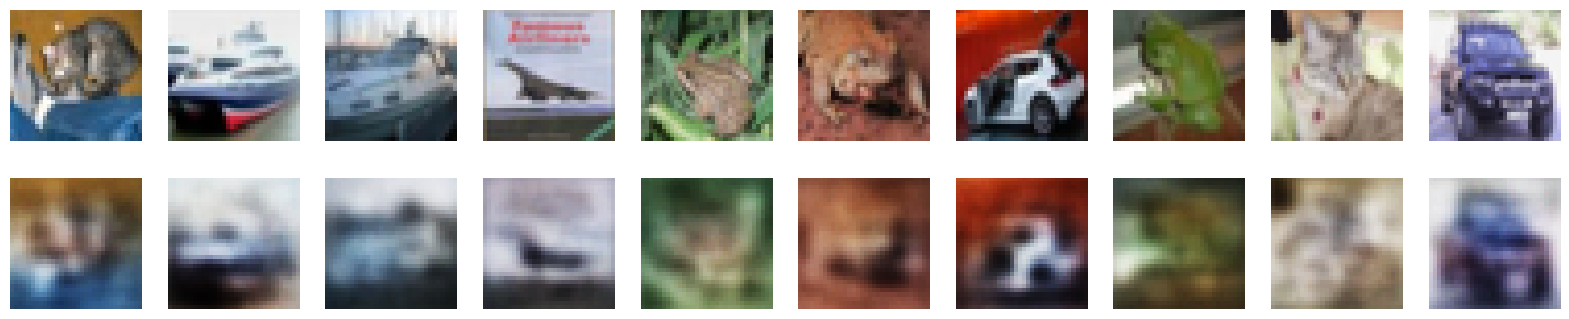

In [ ]:
# basic autoencoder

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten CIFAR images: 32*32*3 = 3072
x_train = x_train.reshape((len(x_train), 3072))
x_test = x_test.reshape((len(x_test), 3072))

# 2. Define Dimensions
input_dim = 3072
encoding_dim = 512  # Larger bottleneck for color complexity

# 3. Build Model
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Train
autoencoder.fit(x_train, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

# 5. Visualize (Color Reconstruction)
decoded_imgs = autoencoder.predict(x_test)

# FIX: Ensure data is float32 and clipped to [0, 1] for matplotlib
decoded_imgs = decoded_imgs.astype('float32')
decoded_imgs = np.clip(decoded_imgs, 0, 1)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original - Also ensure x_test is clipped/float32 just in case
    ax = plt.subplot(2, n, i + 1)
    original = x_test[i].reshape(32, 32, 3).astype('float32')
    plt.imshow(np.clip(original, 0, 1))
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    reconstructed = decoded_imgs[i].reshape(32, 32, 3)
    plt.imshow(reconstructed)
    plt.axis('off')
plt.show()

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.5709 - val_loss: 0.5711
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5706 - val_loss: 0.5705
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5703 - val_loss: 0.5729
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5702 - val_loss: 0.5710
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5701 - val_loss: 0.5702
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5697 - val_loss: 0.5700
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5696 - val_loss: 0.5723
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5697 - val_loss: 0.5698
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5694 - val_loss: 0.5711
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5691 - val_loss: 0.5696
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5690 - val_loss: 0.5731
Epoch 12/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

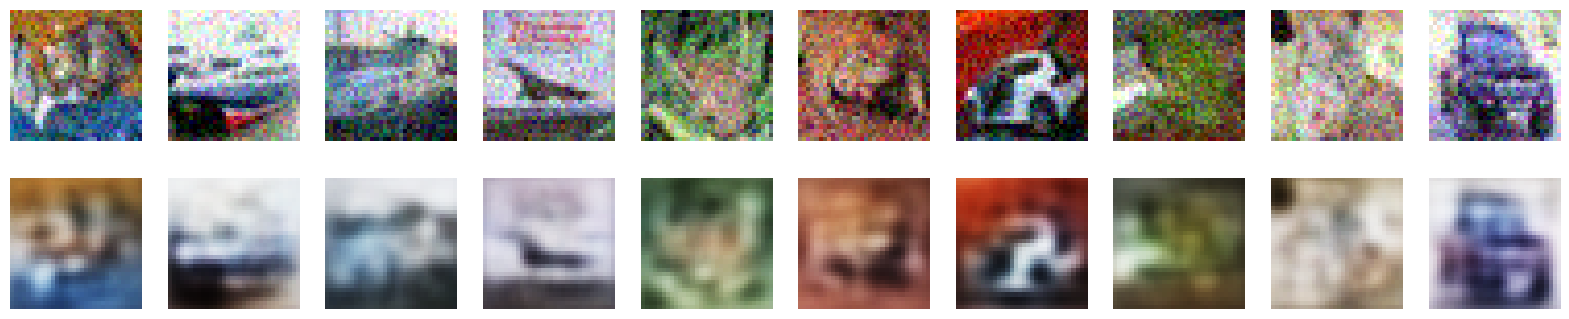

In [ ]:
# denoising autoencoder

# 1. Add Gaussian Noise
noise_factor = 0.1
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 2. Train Model to Denoise (Input = Noisy, Target = Clean)
autoencoder.fit(x_train_noisy, x_train, epochs=20, batch_size=256, validation_data=(x_test_noisy, x_test))

# 3. Visualize Denoising Result
denoised_imgs = autoencoder.predict(x_test_noisy)

plt.figure(figsize=(20, 4))
for i in range(n):
    # Noisy Input
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(32, 32, 3))
    plt.axis('off')

    # Denoised Output
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(denoised_imgs[i].reshape(32, 32, 3))
    plt.axis('off')
plt.show()

Loading CIFAR-10 data...
Starting training...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.5787 - val_loss: 0.5690
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.5647 - val_loss: 0.5640
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5626 - val_loss: 0.5637
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5616 - val_loss: 0.5620
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5607 - val_loss: 0.5610
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5602 - val_loss: 0.5607
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5596 - val_loss: 0.5602
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5593 - val_loss: 0.5597
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.5589 - val_loss: 0.5595
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5586 - val_loss: 0.5591
Generating predictions...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


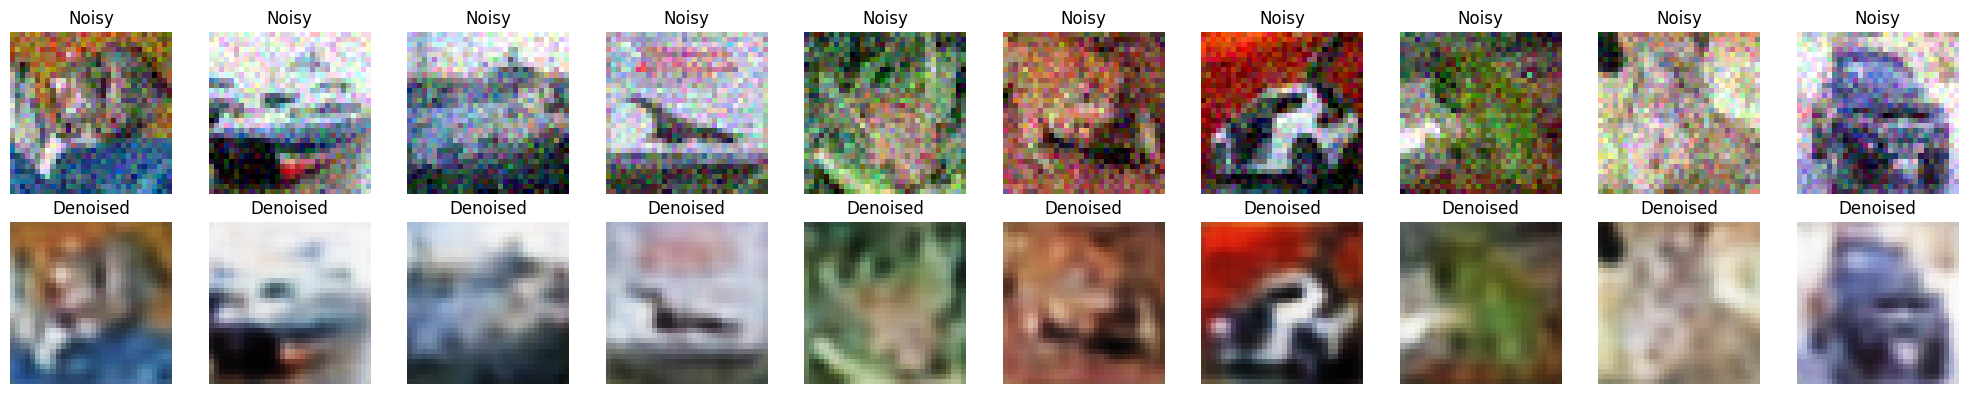

In [ ]:
# Convolutional Denoising Autoencoder

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# 1. Load and Preprocess CIFAR-10
print("Loading CIFAR-10 data...")
(x_train, _), (x_test, _) = cifar10.load_data()

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 2. Add Gaussian Noise
noise_factor = 0.1
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip to ensure pixels stay between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 3. Build the Convolutional Autoencoder Model
input_img = keras.Input(shape=(32, 32, 3))

# --- ENCODER ---
# Reduces spatial dimensions while extracting features
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)
# Latent representation is now (8, 8, 32)

# --- DECODER ---
# Reconstructs the 32x32 image from the bottleneck
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)

# FINAL LAYER: Fixed the missing comma. 3 filters for RGB.
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Define and Compile
autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 4. Train the Model
# We feed NOISY images as input and CLEAN images as the target
print("Starting training...")
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

# 5. Predict and Visualize Results
print("Generating predictions...")
decoded_imgs = autoencoder.predict(x_test_noisy)

# Ensure data is float32 and clipped for Matplotlib safety
decoded_imgs = np.clip(decoded_imgs.astype('float32'), 0, 1)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display Noisy Input
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis('off')

    # Display Denoised (Reconstructed) Output
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# RNN

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from tensorflow.keras.datasets import cifar10

# 1. Load and Preprocess CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# y_train/y_test are one-hot encoded for consistency with your previous experiments
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 2. Build the RNN Model
# We treat the 32x32x3 image as 32 rows (time steps) of 32x3 pixels (features)
model_rnn = Sequential([
    Input(shape=(32, 32 * 3)), # 32 rows, each row has 32 pixels * 3 channels
    SimpleRNN(128, activation='tanh'), # Simple RNN layer with 128 hidden units
    Dense(10, activation='softmax')    # Output layer for 10 classes
])

# 3. Compile the model (using your professor's settings)
model_rnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# 4. Reshape data for RNN
# Reshaping (50000, 32, 32, 3) -> (50000, 32, 96)
x_train_rnn = x_train.reshape(-1, 32, 32 * 3)
x_test_rnn = x_test.reshape(-1, 32, 32 * 3)

# 5. Train the model
print("Training SimpleRNN on CIFAR-10...")
model_rnn.fit(x_train_rnn, y_train, epochs=10, batch_size=128, validation_split=0.2)

# 6. Evaluate
test_loss, test_acc = model_rnn.evaluate(x_test_rnn, y_test, verbose=0)
print(f"RNN Test accuracy: {test_acc:.4f}")

Training SimpleRNN on CIFAR-10...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.2794 - loss: 1.9528 - val_accuracy: 0.2941 - val_loss: 1.9210
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3359 - loss: 1.8112 - val_accuracy: 0.3514 - val_loss: 1.7741
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3630 - loss: 1.7526 - val_accuracy: 0.3737 - val_loss: 1.7360
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3776 - loss: 1.7102 - val_accuracy: 0.3768 - val_loss: 1.7229
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3886 - loss: 1.6779 - val_accuracy: 0.3930 - val_loss: 1.6819
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3970 - loss: 1.6611 - val_accuracy: 0.3917 - val_loss: 1.6782
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4059 - loss: 1.6384 - val_accuracy: 0.3944 - val_loss: 1.6898
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.411

In [ ]:
# next row prediction (image completion logic)

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.datasets import cifar10

# 1. Load Data
(x_train, _), (x_test, _) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0

# 2. Prepare "Next Row" Data
# Input (X): First row of 100 images | Target (y): Second row of those images
# CIFAR-10 row shape: (32 pixels * 3 channels) = 96 features
X_rows = x_train[:100, 0, :].reshape(100, 1, 96)
y_rows = x_train[:100, 1, :].reshape(100, 96)

# 3. Build RNN Model (Mirroring Professor's architecture)
model_next_row = Sequential([
    SimpleRNN(64, input_shape=(1, 96), activation='tanh'),
    Dense(96, activation='sigmoid') # Predicting pixel intensities [0,1]
])
model_next_row.compile(loss='mse', optimizer='adam')

# 4. Train
model_next_row.fit(X_rows, y_rows, epochs=200, verbose=0)

# 5. Predict the next row after the first row of a test image
test_row = x_test[0, 0, :].reshape(1, 1, 96)
pred_row = model_next_row.predict(test_row)
print("Predicted next row shape:", pred_row.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
Predicted next row shape: (1, 96)


In [ ]:
# 1. Ensure x is (50000, 32, 96)
x_train_seq = x_train.reshape(50000, 32, 96)

# 2. Ensure y is (50000,) - This is the "Magic Fix"
# We only take the first column to avoid the 10x multiplier effect
y_train_labels = y_train.reshape(-1)[:50000]

# 3. Double check the shapes before training
print(f"X shape: {x_train_seq.shape}")  # Should be (50000, 32, 96)
print(f"y shape: {y_train_labels.shape}") # Should be (50000,)

# 4. Train
model_sentiment.fit(x_train_seq, y_train_labels, epochs=5, batch_size=64)

X shape: (50000, 32, 96)
y shape: (50000,)
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8988 - loss: 0.3394
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9000 - loss: 0.3264
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9000 - loss: 0.3263
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9000 - loss: 0.3264
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9000 - loss: 0.3262


In [ ]:
# LSTM

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.datasets import cifar10
import numpy as np

# 1. Load and Preprocess CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train.astype('float32') / 255.0, x_test.astype('float32') / 255.0

# 2. Reshape for LSTM: (Samples, Time_Steps, Features)
# A 32x32x3 image = 32 rows (steps), each with 32*3=96 pixels (features)
x_train_lstm = x_train.reshape(-1, 32, 96)
x_test_lstm = x_test.reshape(-1, 32, 96)

# 3. Build the LSTM Model (Mirroring Professor's Logic)
model_lstm = Sequential([
    Input(shape=(32, 96)),
    LSTM(64, return_sequences=False), # LSTM captures long-term row dependencies
    Dense(10, activation='softmax')   # 10 CIFAR classes
])

# 4. Compile (Using sparse_categorical_crossentropy to match professor's loss)
model_lstm.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# 5. Train
print("Training LSTM on CIFAR-10 sequences...")
model_lstm.fit(x_train_lstm, y_train, epochs=10, batch_size=128, validation_split=0.2)

# 6. Predict next class for a test image
sample_test = x_test_lstm[0:1]
pred = model_lstm.predict(sample_test)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(f"Predicted Object: {class_names[np.argmax(pred)]}")

Training LSTM on CIFAR-10 sequences...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2894 - loss: 1.9373 - val_accuracy: 0.3467 - val_loss: 1.7723
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3825 - loss: 1.6910 - val_accuracy: 0.3888 - val_loss: 1.6933
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4225 - loss: 1.5961 - val_accuracy: 0.4283 - val_loss: 1.5882
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4450 - loss: 1.5352 - val_accuracy: 0.4418 - val_loss: 1.5466
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4602 - loss: 1.4921 - val_accuracy: 0.4649 - val_loss: 1.4791
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4746 - loss: 1.4498 - val_accuracy: 0.4802 - val_loss: 1.4516
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4877 - loss: 1.4174 - val_accuracy: 0.4772 - val_loss: 1.4409
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 

Training Image Encoder-Decoder...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0461 - val_loss: 0.0385
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0363 - val_loss: 0.0350
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0337 - val_loss: 0.0331
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0326 - val_loss: 0.0317
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0319 - val_loss: 0.0310
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0309 - val_loss: 0.0305
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0302 - val_loss: 0.0299
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0296 - val_loss: 0.0291
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0290 - val_loss: 0.0283
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0286 - val_loss: 0.0286


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


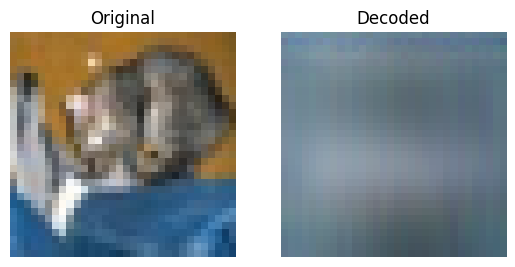

In [ ]:
#encoder and decoder

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, SimpleRNN, Dense, RepeatVector
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10

# 1. Load and Preprocess CIFAR-10
(x_train, _), (x_test, _) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to sequences: (32 rows, 96 pixels/features)
x_train_seq = x_train.reshape(-1, 32, 96)
x_test_seq = x_test.reshape(-1, 32, 96)

# 2. Build Encoder-Decoder Model (Mirroring Professor's RNN state logic)
latent_dim = 64 # The "thought vector" size

# --- ENCODER ---
encoder_inputs = Input(shape=(32, 96))
# return_state=True is the key part of Seq2Seq
encoder_outputs, state_h = SimpleRNN(latent_dim, return_state=True)(encoder_inputs)

# --- DECODER ---
# RepeatVector acts as the bridge, feeding the "thought vector" to every row
decoder_inputs = RepeatVector(32)(state_h)
decoder_rnn = SimpleRNN(latent_dim, return_sequences=True)(decoder_inputs)
decoder_outputs = Dense(96, activation='sigmoid')(decoder_rnn)

# 3. Compile and Train
model_seq2seq = Model(encoder_inputs, decoder_outputs)
model_seq2seq.compile(optimizer='adam', loss='mse')

print("Training Image Encoder-Decoder...")
model_seq2seq.fit(x_train_seq, x_train_seq, epochs=10, batch_size=128, validation_split=0.2)

# 4. Inference: Reconstruct an image
reconstructed_rows = model_seq2seq.predict(x_test_seq[0:1])
reconstructed_img = reconstructed_rows.reshape(32, 32, 3)

# 5. Visualize Result
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1); plt.title("Original"); plt.imshow(x_test[0]); plt.axis('off')
plt.subplot(1, 2, 2); plt.title("Decoded"); plt.imshow(reconstructed_img); plt.axis('off')
plt.show()

In [ ]:
#BERT

import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Simple Transformer Block (BERT logic)
def transformer_block(inputs, embed_dim, num_heads, ff_dim, dropout=0.1):
    # Multi-head Self Attention (The core of BERT)
    attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
    attention_output = layers.Dropout(dropout)(attention_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    # Feed Forward network
    ffn_output = layers.Dense(ff_dim, activation="relu")(out1)
    ffn_output = layers.Dense(embed_dim)(ffn_output)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

# 3. Build Model: Treating the image as a sequence of 32 rows
inputs = layers.Input(shape=(32, 96)) # 32 rows of 96 pixels (32*3)
x = transformer_block(inputs, embed_dim=96, num_heads=2, ff_dim=128)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(10, activation="softmax")(x)

model_vit = models.Model(inputs=inputs, outputs=outputs)
model_vit.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train (Note: Transformers need more data/epochs than CNNs to shine)
model_vit.fit(x_train.reshape(-1, 32, 96), y_train, epochs=5, batch_size=64)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.3163 - loss: 1.8636
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3867 - loss: 1.6886
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4147 - loss: 1.6172
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4330 - loss: 1.5741
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4478 - loss: 1.5378


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# --- Generator: Noise -> 32x32x3 Color Image ---
def build_cifar_generator():
    model = models.Sequential([
        # Use Input layer instead of input_dim to fix the UserWarning
        layers.Input(shape=(100,)),
        layers.Dense(8 * 8 * 128),
        layers.Reshape((8, 8, 128)),
        layers.UpSampling2D(), # 8x8 -> 16x16
        layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"),
        layers.UpSampling2D(), # 16x16 -> 32x32
        layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        layers.Conv2D(3, kernel_size=3, padding="same", activation="tanh") # RGB output
    ])
    return model

# --- Discriminator: 32x32x3 Image -> Real/Fake ---
def build_cifar_discriminator():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(64, kernel_size=3, strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Conv2D(128, kernel_size=3, strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Flatten(),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=Adam(0.0002, 0.5), loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Initialize models
gen = build_cifar_generator()
disc = build_cifar_discriminator()

# --- One Step of Training ---
# Now 'np' will work perfectly
noise = np.random.normal(0, 1, (1, 100))
fake_img = gen.predict(noise)
print("Generated image shape:", fake_img.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Generated image shape: (1, 32, 32, 3)


In [ ]:
pip install matplotlib numpy

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Create the directory using Python
if not os.path.exists('assignment_results'):
    os.makedirs('assignment_results')

# 2. Helper to save
def save_graph(name):
    plt.savefig(f"assignment_results/{name}.png", bbox_inches='tight')
    plt.close()
    print(f"✅ Generated: assignment_results/{name}.png")

# 3. Run your plotting logic
missing_rates = [10, 20, 30, 40, 50]
plt.figure(figsize=(10, 6))
pima = {'RF': [77, 73, 65, 61, 55], 'EC (Proposed)': [75, 73, 64, 60, 56]}
for m, s in pima.items():
    plt.plot(missing_rates, s, marker='o', label=m)
plt.title('Pima F1-Score Comparison'); plt.legend(); plt.grid(True)
save_graph('01_pima_yeast_balance')

# (Paste the rest of your plot_medical and accuracy calls here)

✅ Generated: assignment_results/01_pima_yeast_balance.png
